In [40]:
#!pip install lbforaging

## Foraging

**LB-Foraging** es un entorno *multi-agente* de recolección en cuadrícula con dos modos de juego.

### Espacio de acciones (por agente)

| Acción | Descripción |
|--------|-------------|
| NONE   | No hacer nada |
| NORTH  | Moverse al norte |
| SOUTH  | Moverse al sur |
| WEST   | Moverse al oeste |
| EAST   | Moverse al este |
| LOAD   | Recoger ítem adyacente |

### Observación (por agente)
Cada agente recibe un vector de 9 floats con posición y nivel de los agentes y del ítem visible.

### Recompensas
Un ítem se recoge cuando la suma de niveles de los agentes adyacentes que ejecutan **LOAD** ≥ nivel del ítem.
La recompensa se distribuye entre los participantes. El episodio termina cuando se recoge el ítem o se alcanza el límite de pasos.

### Modos de juego

| Config | `force_coop` | Descripción |
|--------|:---:|---|
| `Foraging-8x8-2p-1f-v3` | ✗ | **Modo mixto**: el nivel del ítem es aleatorio; ~42 % de episodios requieren cooperación y ~58 % son competitivos. |
| `Foraging-8x8-2p-1f-coop-v3` | ✓ | **Modo cooperativo**: la cooperación es **obligatoria** en todos los episodios. |

### Diferencia con juegos matriciales

> A diferencia de MP y RPS, Foraging es un juego **secuencial con estado**. No existe un equilibrio de Nash
> analítico expresable como una distribución sobre acciones, por lo que **no se analiza convergencia de política
> al NE**. En su lugar se reportan métricas de aprendizaje por refuerzo: **recompensa acumulada**, **tasa de éxito**
> y **pasos por episodio**. La línea de referencia Nash en la tasa de éxito es la tasa óptima estimada
> empíricamente, no un NE de estrategia mixta.

In [41]:
import lbforaging
from games.foraging import Foraging
import numpy as np
import time
import matplotlib.pyplot as plt
import os

from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM
from agents.random_agent import RandomAgent
from utils.constants import COLORS, JAL_AM_PALETTE

ImportError: cannot import name 'JAL_AM_PALETTE' from 'utils.constants' (/Users/nataliacampigliastemphelet/master/simultaneous-games/utils/constants.py)

## Configuración de Experimentos

Se definen 4 configuraciones con distinto tamaño de grilla, número de jugadores y horizonte de entrenamiento.
Cada entrada incluye los hiperparámetros del agente y el `train_config` (iteraciones × episodios por iteración).

In [ ]:
def epsilon_decay(max_t, min_eps=0.01):
    """Decay rate so ε reaches min_eps after max_t steps."""
    return min_eps ** (1 / max_t)

configurations = {
    '0': {
        'game':         "Foraging-5x5-2p-1f-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(25_000),    'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(25_000),    'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 10},
    },
    '1': {
        'game':         "Foraging-8x8-2p-1f-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(250_000),   'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(250_000),   'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 50},
    },
    '2': {
        'game':         "Foraging-8x8-3p-1f-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(500_000),   'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(500_000),   'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 100},
    },
    '3': {
        'game':         "Foraging-8x8-3p-1f-coop-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(1_500_000), 'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(1_500_000), 'seed': 1},
        'train_config': {'episodes': 1000, 'iterations': 100},
    },
}

os.makedirs('figures/Foraging', exist_ok=True)

## Funciones de Entrenamiento

Tomadas de IQL.ipynb: `play_episode` incluye `reset()` por episodio y la actualización terminal del paso final,
`run` acumula recompensas, y `train` itera imprimiendo progreso cada 10 iteraciones.

In [ ]:
def play_episode(game, agents, verbose=False, render=False):
    game.reset()
    step_count = 0
    for agent in game.agents:
        if hasattr(agents[agent], 'reset'):
            agents[agent].reset()
    if verbose:
        print(f"Step: {step_count}")
        for agent in game.agents:
            print(f"Agent {agent} observe: {game.observe(agent)}")
    cum_rewards = {agent: 0.0 for agent in game.agents}
    if render:
        game.render()
        time.sleep(0.5)
    while not game.done():
        step_count += 1
        actions = {agent: agents[agent].action() for agent in game.agents}
        game.step(actions)
        for agent in game.agents:
            cum_rewards[agent] += game.reward(agent)
        if verbose:
            print(f"Step: {step_count}")
            for agent in game.agents:
                print(f"  {agent} action: {actions[agent]} - {game.action_set[actions[agent]]}")
                print(f"  {agent} reward: {game.reward(agent)}")
                print(f"  {agent} observe: {game.observe(agent)}")
        if render:
            game.render()
            time.sleep(0.5)
    for agent in game.agents:
        agents[agent].update()
    return cum_rewards


def run(game, agents, episodes=1, verbose=False, render=False):
    sum_rewards = {agent: 0.0 for agent in game.agents}
    for _ in range(episodes):
        cum_rewards = play_episode(game, agents, verbose=verbose, render=render)
        for agent in game.agents:
            sum_rewards[agent] += cum_rewards[agent]
    return sum_rewards

def parse_foraging_observation(obs, n_players):
    obs = list(obs)

    food_y, food_x, food_level = obs[:3]

    players = {}
    offset = 3

    for i in range(n_players):
        y, x, level = obs[offset:offset + 3]
        players[f"P{i}"] = {
            "position": (int(y), int(x)),
            "level": int(level),
        }
        offset += 3

    return {
        "food": {
            "position": (int(food_y), int(food_x)),
            "level": int(food_level),
        },
        "players": players,
    }

def train(game, agents, train_config, progress=False, verbose=False, render=False):
    iterations      = train_config['iterations']
    episodes        = train_config['episodes']
    average_rewards = {agent: [] for agent in game.agents}
    for i in range(1, iterations + 1):
        sum_rewards = run(game, agents, episodes=episodes)
        for agent in game.agents:
            average_rewards[agent].append(sum_rewards[agent] / episodes)
        if progress and (i % 10 == 0):
            print(f"Iteration {i} ({i * episodes} episodes)")
            for agent in game.agents:
                obs = game.observe(agent)
                parsed_obs = parse_foraging_observation(
                    obs,
                    n_players=len(game.agents)
                )
                print(f"  {agent}: {average_rewards[agent][-1]:.4f}")
                print(
                    f"    Food: pos={parsed_obs['food']['position']}, "
                    f"level={parsed_obs['food']['level']}"
                )

                for player_id, player_info in parsed_obs["players"].items():
                    print(
                        f"    {player_id}: pos={player_info['position']}, "
                        f"level={player_info['level']}"
                    )
    if progress:
        print(f"\nFinal — {iterations} iters × {episodes} eps = {iterations * episodes} total episodes")
        for agent in game.agents:
            print(f"  {agent}: {average_rewards[agent][-1]:.4f}")
    return average_rewards


def plot_training(average_rewards, title, colors=None, save_path=None):
    """Recompensa promedio por iteración durante el entrenamiento."""
    default_colors = ['#FF9800', '#FF5722', '#FFC107', '#795548']
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, (agent, rewards) in enumerate(average_rewards.items()):
        color = colors[i] if colors and i < len(colors) else default_colors[i % len(default_colors)]
        ax.plot(rewards, label=agent, color=color)
    ax.set_xlabel('Iteración')
    ax.set_ylabel('Recompensa promedio / episodio')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

## Funciones de Visualización

In [ ]:
def render_board(ax, field, players, grid_size,
                 step=None, actions=None, rewards=None, action_set=None):
    PLAYER_COLORS = ['#1565C0', '#B71C1C', '#1B5E20']
    FOOD_COLOR    = '#2E7D32'
    EMPTY_COLOR   = '#ECEFF1'
    ax.set_facecolor(EMPTY_COLOR)
    for r in range(grid_size):
        for c in range(grid_size):
            color = '#E3E8EE' if (r + c) % 2 == 0 else EMPTY_COLOR
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color=color, zorder=0))
    food_cells = list(zip(*field.nonzero())) if field.any() else []
    for r, c in food_cells:
        ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
                                    color=FOOD_COLOR, zorder=2, linewidth=1.5, edgecolor='#1B5E20'))
        ax.text(c, r, 'F\nlv' + str(int(field[r, c])),
                ha='center', va='center', fontsize=6, fontweight='bold', color='white', zorder=3)
    for i, (pr, pc, plevel) in enumerate(players):
        color = PLAYER_COLORS[i % len(PLAYER_COLORS)]
        ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,
                                    color=color, zorder=2, linewidth=1.5, edgecolor='black'))
        act_lbl = ''
        if actions is not None and action_set is not None:
            key = 'agent_' + str(i)
            if key in actions:
                act_lbl = '\n' + action_set[actions[key]][:3]
        ax.text(pc, pr, 'P' + str(i) + act_lbl,
                ha='center', va='center', fontsize=7, color='white', fontweight='bold', zorder=3)
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.tick_params(labelsize=5, length=0)
    got_reward = rewards and any(v > 0 for v in rewards.values())
    title = ('Step ' + str(step)) if step is not None else 'Inicio'
    if got_reward:
        title += ' ✓'
    ax.set_title(title, fontsize=8, pad=2, color='#2E7D32' if got_reward else 'black')


def run_episode_visual(game, agents, max_display=None, title='', seed=None):
    game.reset(seed=seed)
    env = game.env.unwrapped
    grid_size = env.field.shape[0]
    frames = []

    def snap(step, actions=None, rewards=None):
        frames.append({
            'step':    step,
            'actions': dict(actions) if actions else None,
            'rewards': dict(rewards) if rewards else None,
            'field':   env.field.copy(),
            'players': [(p.position[0], p.position[1], p.level) for p in env.players],
        })

    snap(0)
    cum_rewards = {a: 0.0 for a in game.agents}
    while not game.done():
        actions  = {a: agents[a].action() for a in game.agents}
        game.step(actions)
        step_rew = {a: game.reward(a) for a in game.agents}
        for a in game.agents:
            cum_rewards[a] += step_rew[a]
        snap(game.current_step, actions, step_rew)
    if max_display is not None and len(frames) > max_display:
        idx = list(np.linspace(0, len(frames) - 1, max_display, dtype=int))
        frames = [frames[i] for i in sorted(set(idx))]
    n    = len(frames)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.9, rows * 2.3))
    axes_flat = np.array(axes).flatten() if n > 1 else np.array([axes])
    for ax, fr in zip(axes_flat, frames):
        render_board(ax, fr['field'], fr['players'], grid_size,
                      step=fr['step'], actions=fr['actions'],
                      rewards=fr['rewards'], action_set=game.action_set)
    for ax in axes_flat[len(frames):]:
        ax.set_visible(False)
    legend_parts = [f'P{i} ({a}): {round(cum_rewards[a], 2)}' for i, a in enumerate(game.agents)]
    legend = '  |  '.join(legend_parts) + f'  |  {game.current_step} pasos total'
    if title:
        legend = title + '\n' + legend
    plt.suptitle(legend, fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return cum_rewards, game.current_step


def show_trained_game(game, agents, label, max_tries=30):
    """Visualiza un episodio con agentes pre-entrenados (ε=0). Busca la primera seed exitosa."""
    found_seed = None
    for seed in range(1, max_tries + 1):
        for ag in agents.values():
            if hasattr(ag, 'reset'):
                ag.reset()
        game.reset(seed=seed)
        cum = {a: 0.0 for a in game.agents}
        while not game.done():
            acts = {a: agents[a].action() for a in game.agents}
            game.step(acts)
            for a in game.agents:
                cum[a] += game.reward(a)
        if sum(cum.values()) > 0:
            found_seed = seed
            break
    use_seed = found_seed if found_seed is not None else 1
    suffix   = '' if found_seed else ' — sin éxito'
    for ag in agents.values():
        if hasattr(ag, 'reset'):
            ag.reset()
    run_episode_visual(game, agents, max_display=None, title=label + suffix, seed=use_seed)

## Exploración del Entorno

Se ejecuta un episodio completo con agentes aleatorios mostrando el tablero en cada step.
Cada celda muestra la posición de los jugadores **P0** (azul) y **P1** (rojo),
la comida **F** (verde) con su nivel, y la acción tomada en ese step.
El título del step se marca con ✓ cuando se recoge comida.

/Users/nataliacampigliastemphelet/master/simultaneous-games/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


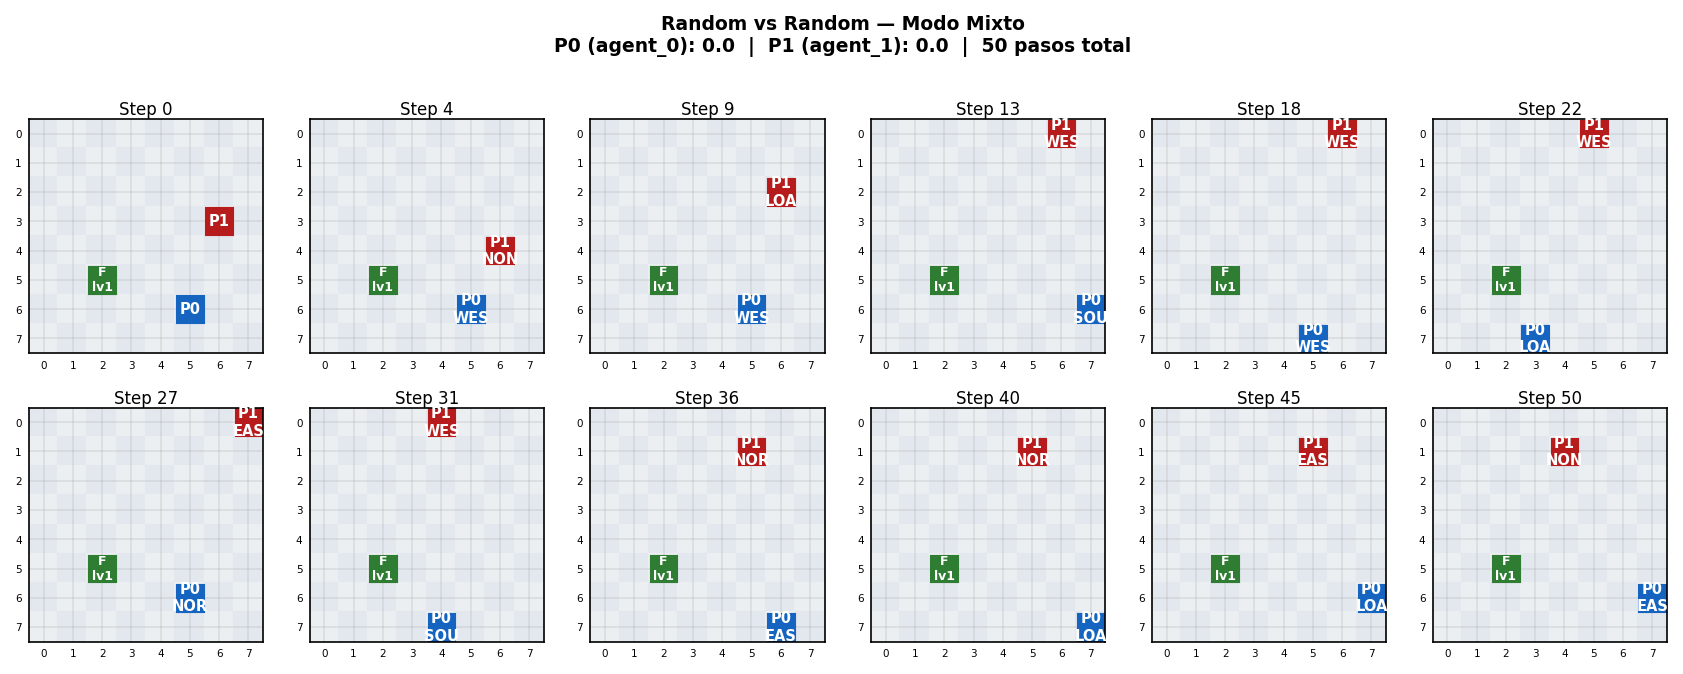

({'agent_0': 0.0, 'agent_1': 0.0}, 50)

In [ ]:
# Modo Mixto
_g_exp = Foraging(config=None, seed=42)
_agents_exp = {a: RandomAgent(game=_g_exp, agent=a) for a in _g_exp.agents}
run_episode_visual(_g_exp, _agents_exp, max_display=12,
                    title='Random vs Random — Modo Mixto')

## Experimentos: IQL, JAL-AM y equipos mixtos

Para cada una de las 4 configuraciones se entrena **IQL** y **JAL-AM** en self-play.
En las configuraciones 3-player (configs 2 y 3) se añaden experimentos mixtos:
- JAL-AM × 2 + IQL × 1
- IQL × 2 + JAL-AM × 1

### Configuración 0 — `Foraging-5x5-2p-1f-v3`

Grilla 5×5, 2 jugadores, 1 ítem. Horizonte corto: 10 iteraciones × 100 episodios = 1 000 episodios totales.

=== IQL — Foraging-5x5-2p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.7400, Observed state: [-1. -1.  0.  2.  1.  2.  1.  0.  2.]
  agent_1: 0.2100, Observed state: [-1. -1.  0.  1.  0.  2.  2.  1.  2.]

Final — 10 iters × 100 eps = 1000 total episodes
  agent_0: 0.7400
  agent_1: 0.2100


/Users/nataliacampigliastemphelet/master/simultaneous-games/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(


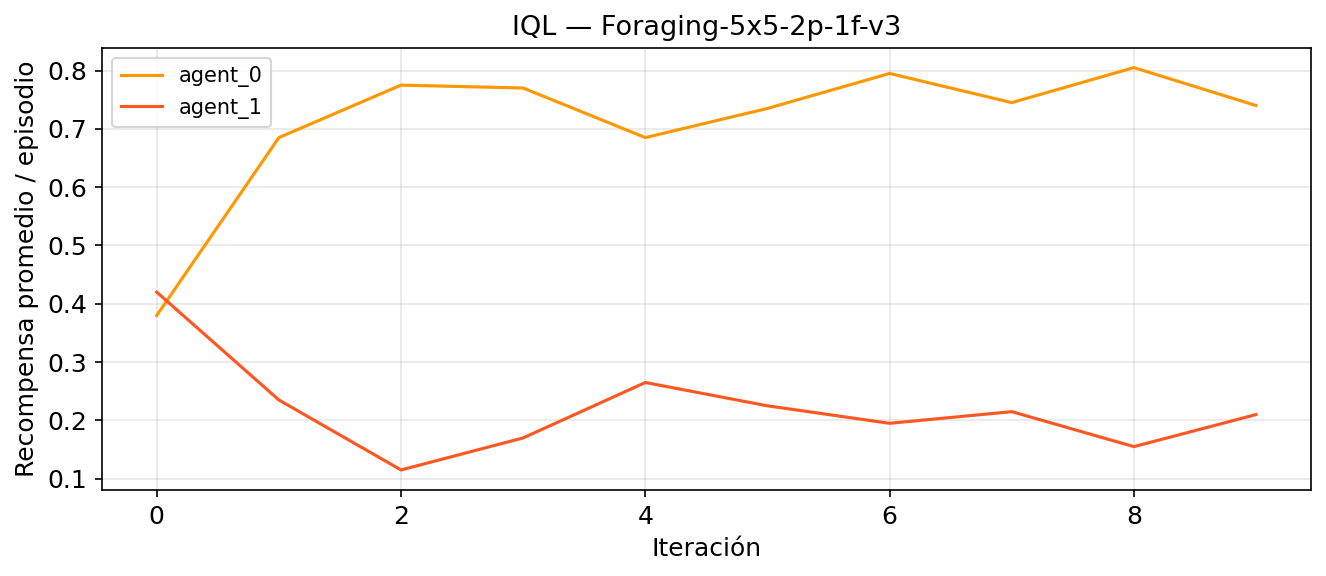

In [ ]:
# ── IQL — Config 0: Foraging-5x5-2p-1f-v3 ────────────────────────────────────
config = configurations['0']
game_iql_0 = Foraging(config=config['game'], seed=1)
agents_iql_0 = {a: IndependentQLearning(game=game_iql_0, agent=a, **config['iql'])
                for a in game_iql_0.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_0 = train(game_iql_0, agents_iql_0, config['train_config'], progress=True)

plot_training(avg_iql_0,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722'],
              save_path='figures/Foraging/iql_config0_training.png')

for a in game_iql_0.agents:
    agents_iql_0[a].epsilon = 0.0
    agents_iql_0[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


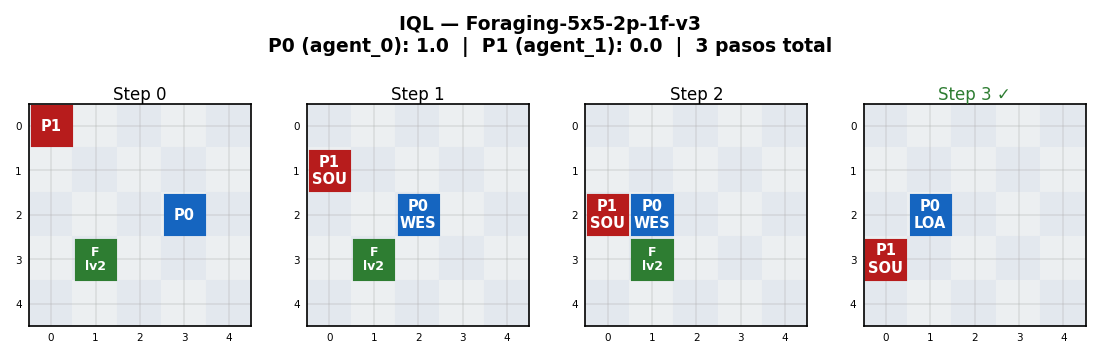

In [ ]:
show_trained_game(game_iql_0, agents_iql_0, f'IQL — {configurations["0"]["game"]}')

#### Observaciones
En este experimento puede observarse un comportamiento bastante desbalanceado entre ambos agentes utilizando Independent Q-Learning en el ambiente `Foraging-5x5-2p-1f-v3`.

Durante las primeras iteraciones ambos agentes comienzan con recompensas relativamente similares, pero rápidamente el agente `agent\_0` incrementa significativamente su recompensa promedio por episodio, estabilizándose alrededor de valores cercanos a $0.75 - 0.8$. En cambio, el agente `agent\_1` reduce progresivamente su recompensa y permanece en valores considerablemente menores.

Esto sugiere que uno de los agentes logra aprender una política más efectiva para alcanzar o recolectar el recurso disponible, mientras que el otro agente queda parcialmente “dominado” o desplazado durante el entrenamiento.

Además, el comportamiento observado resulta consistente con una de las limitaciones principales de Independent Q-Learning en ambientes multiagente: cada agente aprende de manera independiente asumiendo un entorno estacionario, aunque en realidad las políticas de los demás agentes cambian continuamente. Esto puede generar dinámicas inestables o estrategias donde un agente termina explotando mejor el ambiente que el otro.

También puede observarse que las recompensas parecen estabilizarse relativamente rápido, lo cual tiene sentido considerando que el ambiente utilizado es pequeño, contiene únicamente un recurso y posee una cantidad reducida de agentes.

En conjunto, los resultados muestran que IQL logra aprender comportamientos útiles en Foraging, aunque no necesariamente conduce a soluciones balanceadas o coordinadas entre los agentes.

=== JAL-AM — Foraging-5x5-2p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.7083
  agent_1: 0.2617

Final — 10 iters × 100 eps = 1000 total episodes
  agent_0: 0.7083
  agent_1: 0.2617


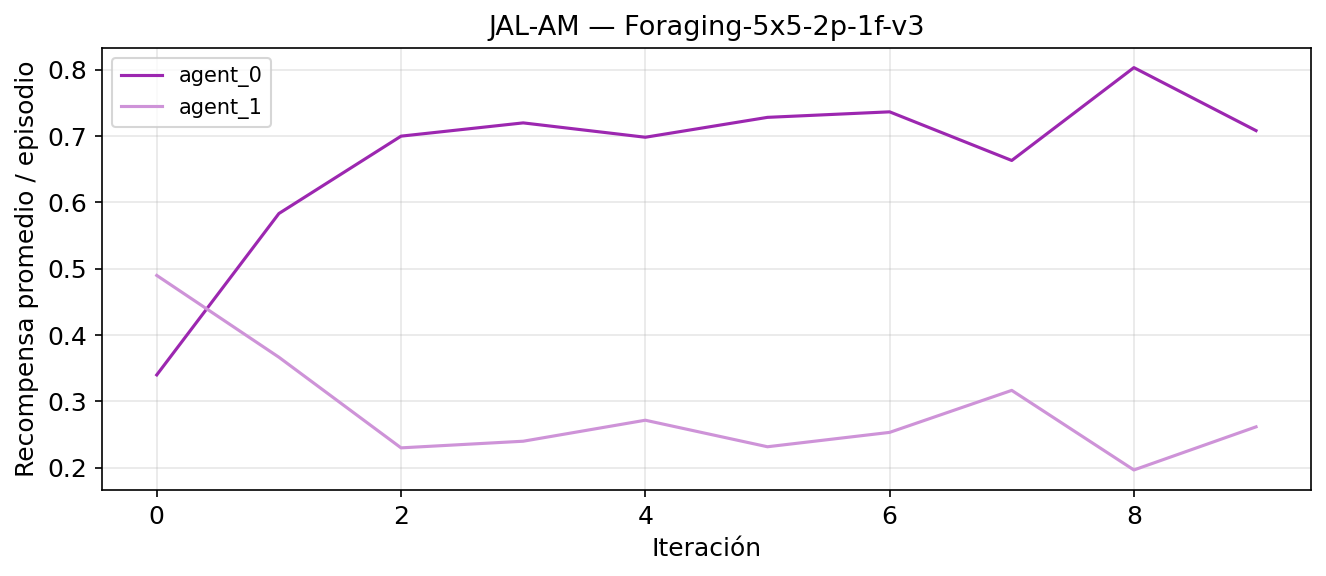

In [ ]:
# ── JAL-AM — Config 0: Foraging-5x5-2p-1f-v3 ─────────────────────────────────
config = configurations['0']
game_jalam_0 = Foraging(config=config['game'], seed=1)
agents_jalam_0 = {a: JointActionLearningAM(game=game_jalam_0, agent=a, **config['jalam'])
                  for a in game_jalam_0.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_0 = train(game_jalam_0, agents_jalam_0, config['train_config'], progress=True)

plot_training(avg_jalam_0,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1]],
              save_path='figures/Foraging/jalam_config0_training.png')

for a in game_jalam_0.agents:
    agents_jalam_0[a].epsilon = 0.0
    agents_jalam_0[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


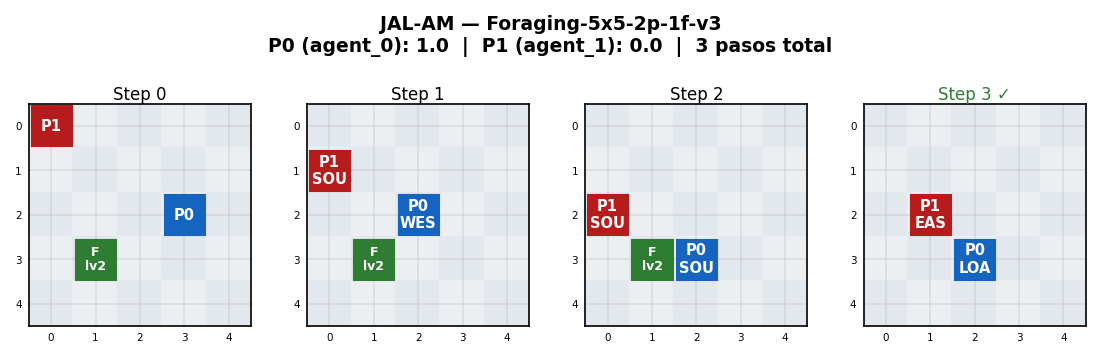

In [ ]:
show_trained_game(game_jalam_0, agents_jalam_0, f'JAL-AM — {configurations["0"]["game"]}')

#### Observaciones
En este experimento utilizando JAL-AM en `Foraging-5x5-2p-1f-v3` puede observarse un comportamiento similar al visto anteriormente con IQL, aunque ligeramente más estable durante el entrenamiento.

Las recompensas muestran nuevamente un escenario desbalanceado entre ambos agentes. El agente `agent\_0`} logra incrementar rápidamente su recompensa promedio hasta estabilizarse alrededor de valores cercanos a $0.7 - 0.8$, mientras que `agent\_1` mantiene recompensas considerablemente menores durante casi todo el entrenamiento.

Esto sugiere que uno de los agentes logra aprender una política más eficiente para alcanzar y recolectar el recurso disponible dentro del mapa. Sin embargo, a diferencia de IQL, las curvas parecen presentar menos oscilaciones y una evolución más estable a lo largo de las iteraciones.

Además, la visualización del episodio entrenado muestra que ambos agentes parecen moverse de forma relativamente coordinada hacia la comida. En los primeros pasos puede observarse que ambos agentes reducen progresivamente la distancia respecto al recurso hasta que finalmente uno de ellos ejecuta la acción de carga (`LOAD`) y recolecta la comida exitosamente en únicamente 3 pasos.

Esto sugiere que JAL-AM logra modelar parcialmente el comportamiento del otro agente y utilizar esa información para tomar decisiones más eficientes dentro del entorno. Sin embargo, el reparto final de recompensas continúa siendo desigual, indicando que el aprendizaje todavía favorece más a uno de los agentes que al otro.

En conjunto, los resultados muestran que JAL-AM logra un comportamiento más estable y coordinado que IQL en este ambiente pequeño de Foraging, aunque todavía no se observa una coordinación completamente balanceada entre ambos agentes.

### Configuración 1 — `Foraging-8x8-2p-1f-v3`

Grilla 8×8, 2 jugadores, 1 ítem. Mayor espacio de estado: 50 iteraciones × 100 episodios = 5 000 episodios totales.

=== IQL — Foraging-8x8-2p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.7300
  agent_1: 0.2200
Iteration 20 (2000 episodes)
  agent_0: 0.7500
  agent_1: 0.2500
Iteration 30 (3000 episodes)
  agent_0: 0.7100
  agent_1: 0.2800
Iteration 40 (4000 episodes)
  agent_0: 0.7050
  agent_1: 0.2950
Iteration 50 (5000 episodes)
  agent_0: 0.7300
  agent_1: 0.2700

Final — 50 iters × 100 eps = 5000 total episodes
  agent_0: 0.7300
  agent_1: 0.2700


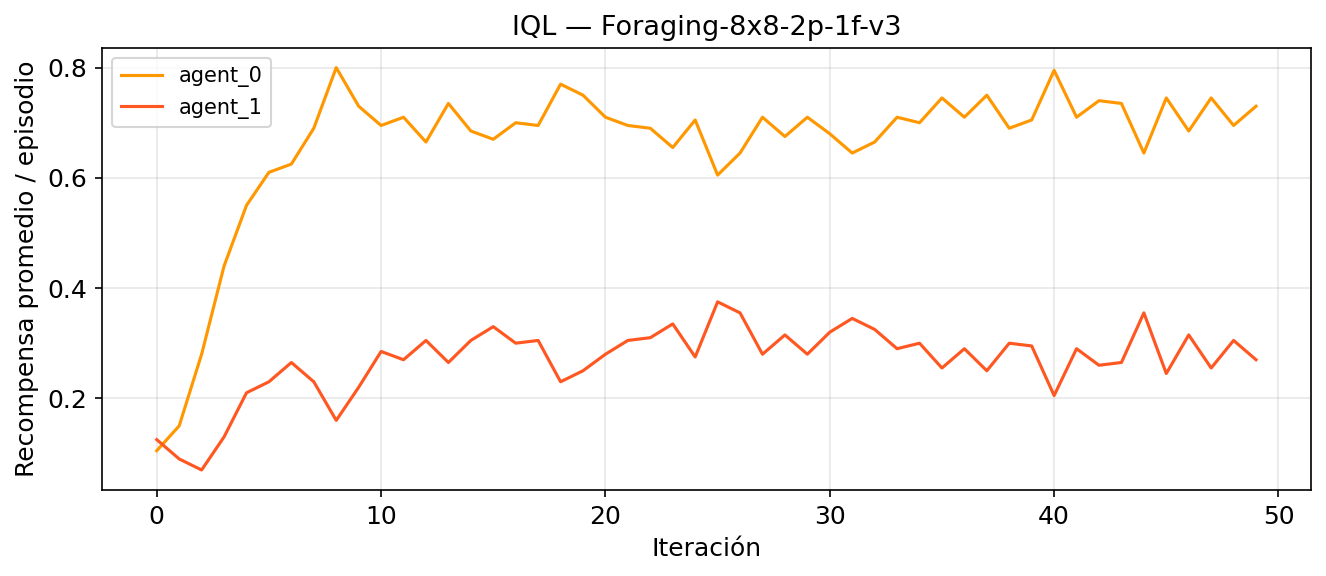

In [ ]:
# ── IQL — Config 1: Foraging-8x8-2p-1f-v3 ────────────────────────────────────
config = configurations['1']
game_iql_1 = Foraging(config=config['game'], seed=1)
agents_iql_1 = {a: IndependentQLearning(game=game_iql_1, agent=a, **config['iql'])
                for a in game_iql_1.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_1 = train(game_iql_1, agents_iql_1, config['train_config'], progress=True)

plot_training(avg_iql_1,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722'],
              save_path='figures/Foraging/iql_config1_training.png')

for a in game_iql_1.agents:
    agents_iql_1[a].epsilon = 0.0
    agents_iql_1[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


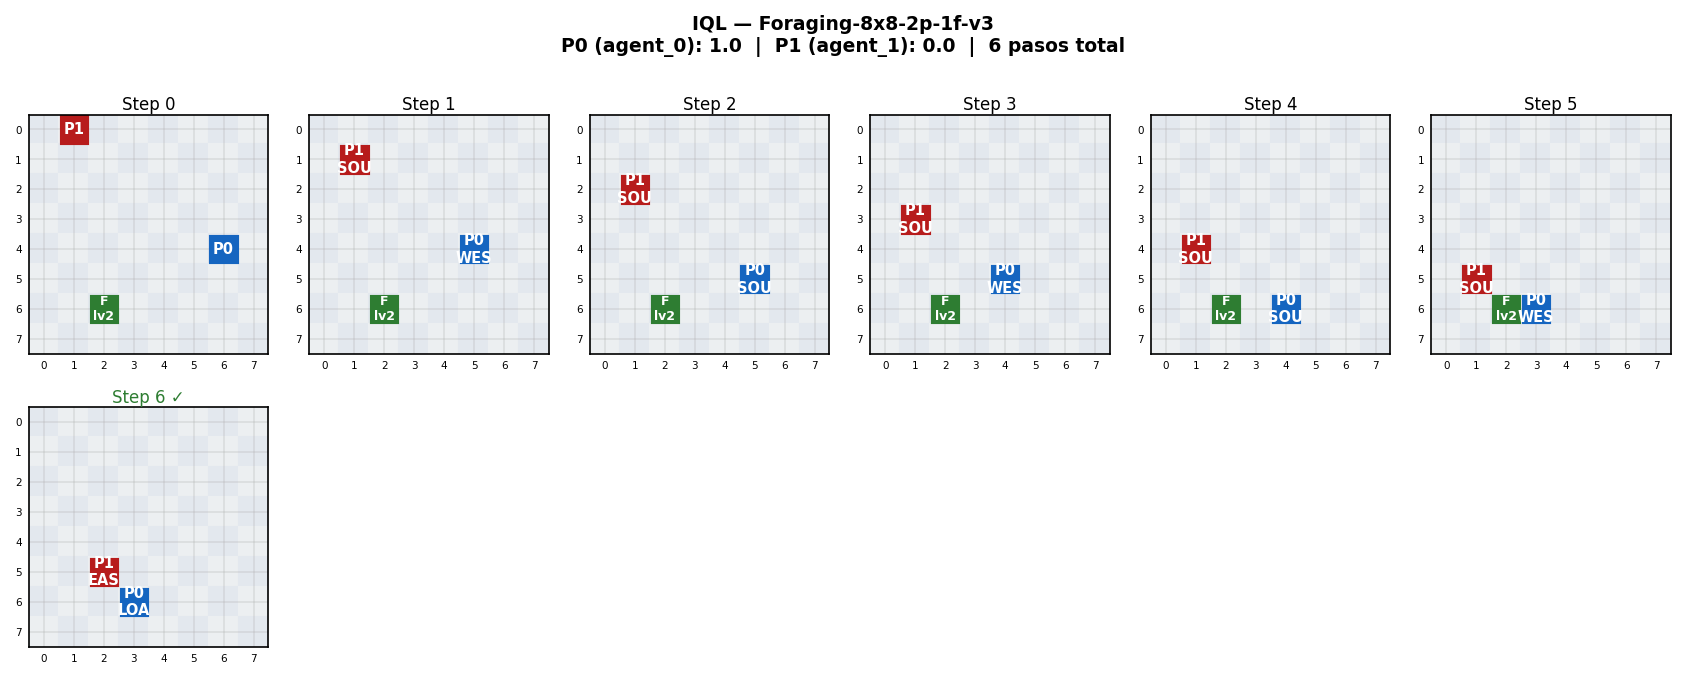

In [ ]:
show_trained_game(game_iql_1, agents_iql_1, f'IQL — {configurations["1"]["game"]}')

#### Observaciones
En este experimento utilizando Independent Q-Learning en `Foraging-8x8-2p-1f-v3` puede observarse un comportamiento similar al visto en la configuración 5x5, aunque el ambiente más grande introduce una mayor dificultad para los agentes.

Las recompensas muestran nuevamente un escenario desbalanceado entre ambos agentes. El agente `agent_0` logra incrementar rápidamente su recompensa promedio hasta estabilizarse alrededor de valores cercanos a $0.7 - 0.8$, mientras que `agent_1` mantiene recompensas considerablemente menores durante casi todo el entrenamiento.

Sin embargo, en comparación con el ambiente 5x5, las recompensas presentan mayores fluctuaciones y una convergencia más lenta durante las primeras iteraciones. Esto resulta razonable ya que el mapa 8x8 posee un espacio de estados más grande, requiriendo mayor exploración para encontrar estrategias efectivas.

Además, la visualización del episodio entrenado muestra que ambos agentes logran desplazarse hacia la comida eficientemente. Puede observarse que el agente `P0` alcanza primero la posición cercana al recurso y finalmente ejecuta la acción `LOAD`, recolectando exitosamente la comida luego de 6 pasos.

El hecho de que ambos agentes se aproximen al recurso sugiere cierto grado de aprendizaje útil del entorno. Sin embargo, nuevamente el reparto de recompensas termina siendo desigual, indicando que uno de los agentes aprende una política significativamente más efectiva que el otro.

También puede observarse que la cantidad total de pasos necesarios para completar el episodio aumenta respecto al ambiente 5x5, algo esperable debido al mayor tamaño del mapa y a la necesidad de recorrer mayores distancias para alcanzar el recurso.

En conjunto, los resultados muestran que IQL continúa siendo capaz de aprender estrategias útiles en ambientes más grandes de Foraging, aunque las dificultades asociadas a la exploración y a la no estacionariedad del entorno se vuelven más evidentes a medida que aumenta la complejidad del problema.

=== JAL-AM — Foraging-8x8-2p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.6450
  agent_1: 0.3150
Iteration 20 (2000 episodes)
  agent_0: 0.6500
  agent_1: 0.3400
Iteration 30 (3000 episodes)
  agent_0: 0.6800
  agent_1: 0.3200
Iteration 40 (4000 episodes)
  agent_0: 0.6800
  agent_1: 0.3200
Iteration 50 (5000 episodes)
  agent_0: 0.6250
  agent_1: 0.3750

Final — 50 iters × 100 eps = 5000 total episodes
  agent_0: 0.6250
  agent_1: 0.3750


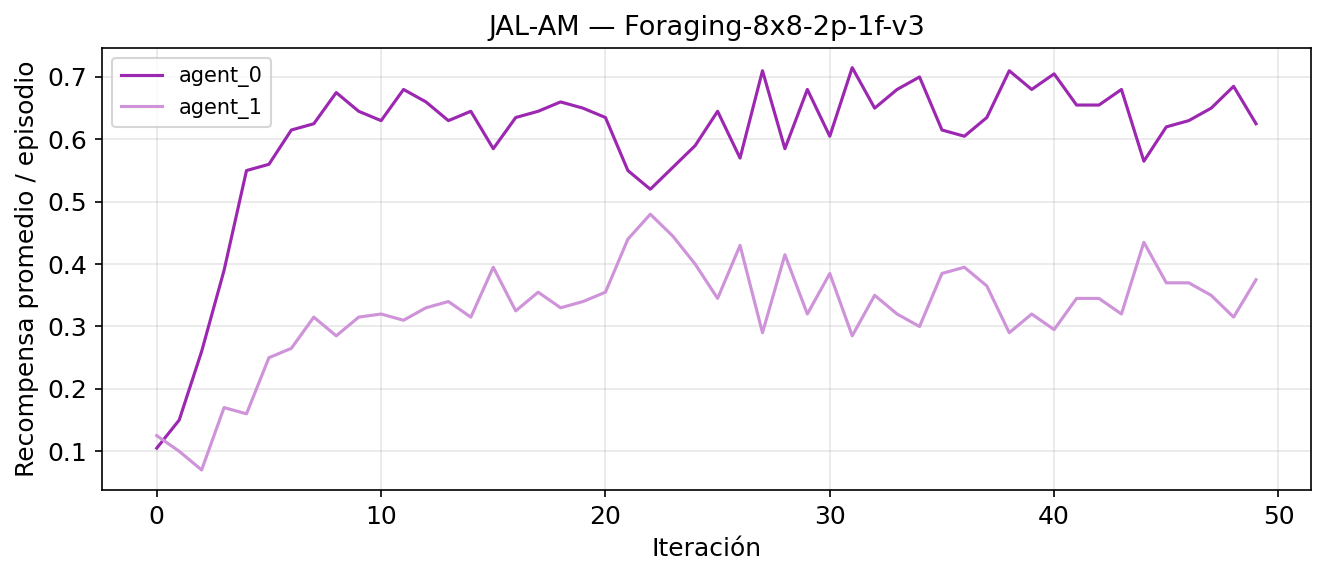

In [ ]:
# ── JAL-AM — Config 1: Foraging-8x8-2p-1f-v3 ─────────────────────────────────
config = configurations['1']
game_jalam_1 = Foraging(config=config['game'], seed=1)
agents_jalam_1 = {a: JointActionLearningAM(game=game_jalam_1, agent=a, **config['jalam'])
                  for a in game_jalam_1.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_1 = train(game_jalam_1, agents_jalam_1, config['train_config'], progress=True)

plot_training(avg_jalam_1,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1]],
              save_path='figures/Foraging/jalam_config1_training.png')

for a in game_jalam_1.agents:
    agents_jalam_1[a].epsilon = 0.0
    agents_jalam_1[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


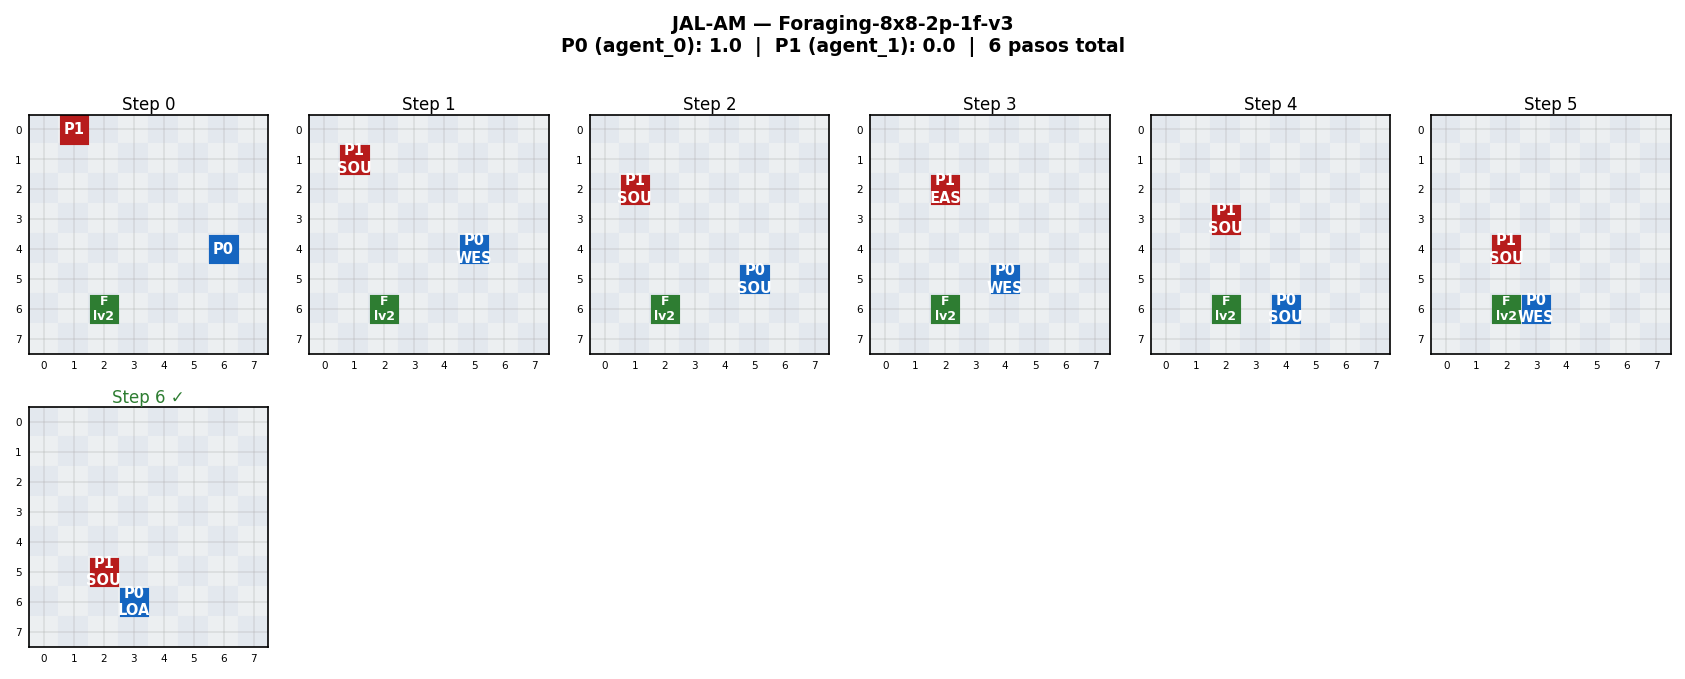

In [ ]:
show_trained_game(game_jalam_1, agents_jalam_1, f'JAL-AM — {configurations["1"]["game"]}')

#### Observaciones
En este experimento utilizando JAL-AM en `Foraging-8x8-2p-1f-v3` puede observarse un comportamiento relativamente más estable que el obtenido previamente con IQL en el mismo ambiente.

Las recompensas muestran nuevamente un escenario desbalanceado entre ambos agentes, donde `agent_0` obtiene consistentemente recompensas promedio considerablemente mayores que `agent_1`. Sin embargo, en este caso el segundo agente logra mantener recompensas más altas y estables que las observadas con IQL, sugiriendo una mejor adaptación al entorno.

Además, las curvas presentan una evolución más suave y con menos fluctuaciones bruscas durante el entrenamiento. Esto indica que JAL-AM logra estabilizar parcialmente el aprendizaje gracias al modelado explícito de las acciones del otro agente.

La visualización del episodio entrenado también muestra un comportamiento interesante. Ambos agentes se mueven de manera eficiente hacia la comida, acercándose progresivamente al recurso hasta que finalmente `P0` ejecuta la acción `LOAD` y recolecta exitosamente la comida luego de 6 pasos.

Puede observarse además que ambos agentes terminan muy próximos al recurso al finalizar el episodio, lo cual sugiere cierto grado de coordinación implícita o al menos una mejor comprensión compartida del objetivo dentro del entorno.

Al igual que en la configuración anterior, el aumento del tamaño del mapa introduce una mayor dificultad de exploración y requiere trayectorias más largas para alcanzar el recurso. Sin embargo, JAL-AM parece adaptarse relativamente bien a esta complejidad adicional y mantener un comportamiento más estable que IQL.

En conjunto, los resultados muestran que JAL-AM logra aprender políticas efectivas y relativamente estables en ambientes más grandes de Foraging. Aunque continúa existiendo un reparto desigual de recompensas entre agentes, el modelado del oponente parece ayudar a mejorar la coordinación y reducir parcialmente los problemas de no estacionariedad presentes en Independent Q-Learning.

### Configuración 2 — `Foraging-8x8-3p-1f-v3`

Grilla 8×8, **3 jugadores**, 1 ítem. Espacio de estado y acción conjunto más grande: 100 iteraciones × 100 episodios = 10 000 episodios totales.

=== IQL — Foraging-8x8-3p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.1800
  agent_1: 0.0300
  agent_2: 0.0700
Iteration 20 (2000 episodes)
  agent_0: 0.1933
  agent_1: 0.2183
  agent_2: 0.2183
Iteration 30 (3000 episodes)
  agent_0: 0.1667
  agent_1: 0.3083
  agent_2: 0.3450
Iteration 40 (4000 episodes)
  agent_0: 0.1317
  agent_1: 0.3608
  agent_2: 0.3875
Iteration 50 (5000 episodes)
  agent_0: 0.1367
  agent_1: 0.3883
  agent_2: 0.3950
Iteration 60 (6000 episodes)
  agent_0: 0.1067
  agent_1: 0.4217
  agent_2: 0.4417
Iteration 70 (7000 episodes)
  agent_0: 0.1500
  agent_1: 0.3983
  agent_2: 0.4317
Iteration 80 (8000 episodes)
  agent_0: 0.1000
  agent_1: 0.4283
  agent_2: 0.4217
Iteration 90 (9000 episodes)
  agent_0: 0.0983
  agent_1: 0.4358
  agent_2: 0.4258
Iteration 100 (10000 episodes)
  agent_0: 0.0783
  agent_1: 0.4342
  agent_2: 0.4375

Final — 100 iters × 100 eps = 10000 total episodes
  agent_0: 0.0783
  agent_1: 0.4342
  agent_2: 0.4375


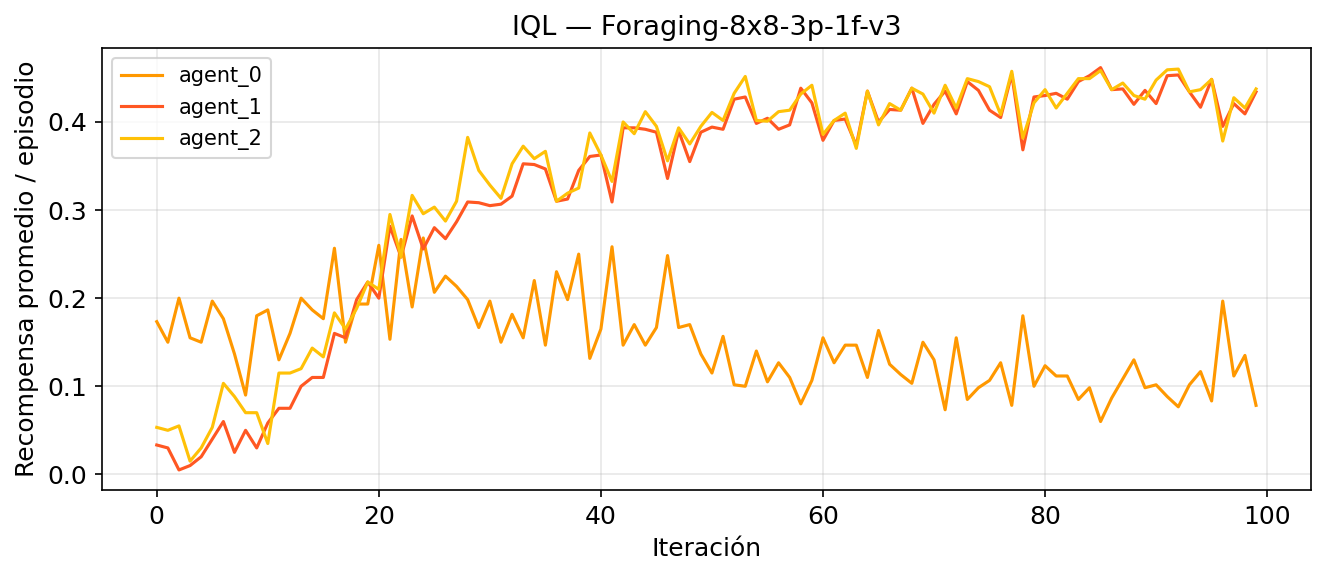

In [ ]:
# ── IQL — Config 2: Foraging-8x8-3p-1f-v3 ────────────────────────────────────
config = configurations['2']
game_iql_2 = Foraging(config=config['game'], seed=1)
agents_iql_2 = {a: IndependentQLearning(game=game_iql_2, agent=a, **config['iql'])
                for a in game_iql_2.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_2 = train(game_iql_2, agents_iql_2, config['train_config'], progress=True)

plot_training(avg_iql_2,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', '#FFC107'],
              save_path='figures/Foraging/iql_config2_training.png')

for a in game_iql_2.agents:
    agents_iql_2[a].epsilon = 0.0
    agents_iql_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


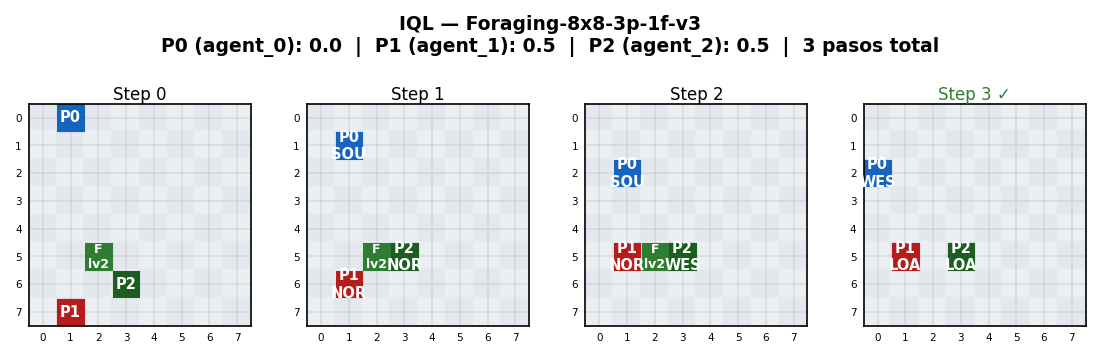

In [ ]:
show_trained_game(game_iql_2, agents_iql_2, f'IQL — {configurations["2"]["game"]}')

#### Observaciones

En este experimento utilizando Independent Q-Learning en `Foraging-8x8-3p-1f-v3` puede observarse un comportamiento diferente respecto a las configuraciones anteriores con únicamente dos agentes.

Las recompensas muestran una dinámica más distribuida entre los jugadores. Mientras que `agent_1` y `agent_2` logran incrementar progresivamente sus recompensas promedio hasta alcanzar valores cercanos a $0.4 - 0.45$, `agent_0` mantiene recompensas considerablemente menores durante gran parte del entrenamiento.

A diferencia de los escenarios de dos jugadores, aquí puede observarse que dos agentes parecen beneficiarse simultáneamente del aprendizaje, mientras que un tercer agente queda parcialmente desplazado. Esto sugiere que la presencia de un tercer jugador aumenta la complejidad de coordinación dentro del entorno.

La visualización del episodio entrenado muestra que `P1` y `P2` ejecutan la acción `LOAD` cerca del recurso, mientras que `P0` permanece más alejado. Como resultado, las recompensas finales fueron aproximadamente: `P0 = 0.0`, `P1 = 0.5` y `P2 = 0.5`.

Esto sugiere que algunos agentes lograron coordinarse mejor que otros para recolectar exitosamente la comida. Además, el episodio se completa en únicamente 3 pasos, indicando que los agentes aprendieron una trayectoria eficiente hacia el recurso.

En conjunto, los resultados muestran que IQL logra aprender comportamientos útiles incluso en escenarios con tres agentes, aunque la coordinación y distribución de recompensas se vuelven más complejas a medida que aumenta la cantidad de jugadores.

=== JAL-AM — Foraging-8x8-3p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.1700
  agent_1: 0.0400
  agent_2: 0.0900
Iteration 20 (2000 episodes)
  agent_0: 0.2667
  agent_1: 0.1667
  agent_2: 0.2067
Iteration 30 (3000 episodes)
  agent_0: 0.3650
  agent_1: 0.2525
  agent_2: 0.2725
Iteration 40 (4000 episodes)
  agent_0: 0.1883
  agent_1: 0.3275
  agent_2: 0.3242
Iteration 50 (5000 episodes)
  agent_0: 0.1483
  agent_1: 0.3842
  agent_2: 0.3775
Iteration 60 (6000 episodes)
  agent_0: 0.1400
  agent_1: 0.4033
  agent_2: 0.3967
Iteration 70 (7000 episodes)
  agent_0: 0.1850
  agent_1: 0.3975
  agent_2: 0.4075
Iteration 80 (8000 episodes)
  agent_0: 0.1667
  agent_1: 0.4100
  agent_2: 0.4233
Iteration 90 (9000 episodes)
  agent_0: 0.1400
  agent_1: 0.4233
  agent_2: 0.3967
Iteration 100 (10000 episodes)
  agent_0: 0.1317
  agent_1: 0.4325
  agent_2: 0.4358

Final — 100 iters × 100 eps = 10000 total episodes
  agent_0: 0.1317
  agent_1: 0.4325
  agent_2: 0.4358


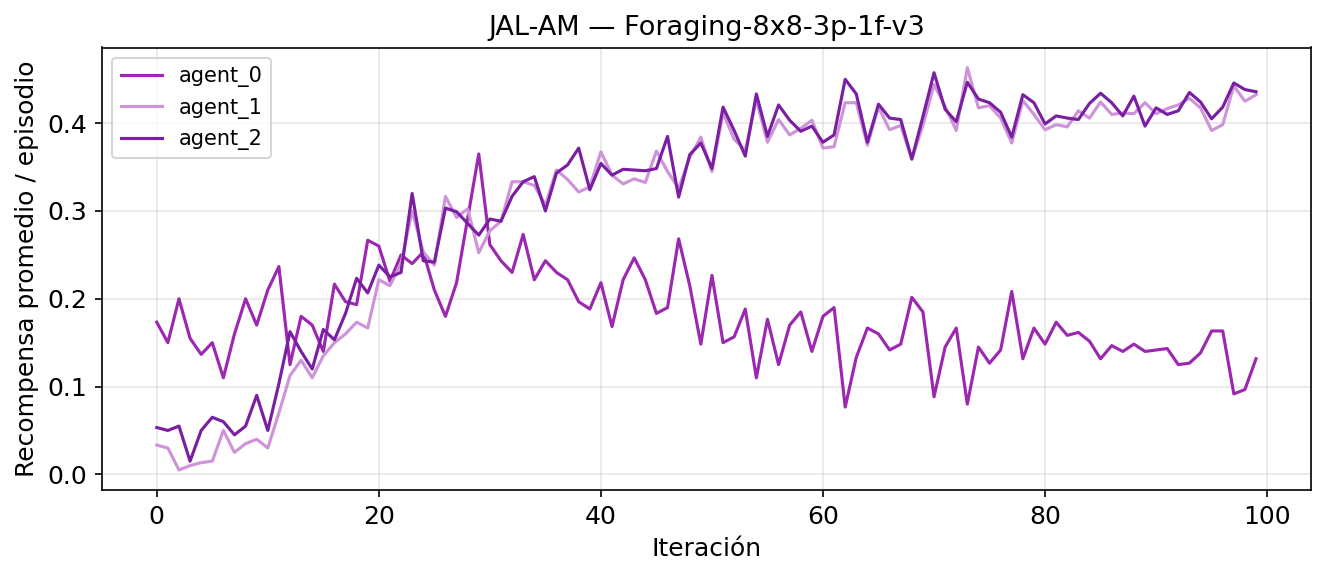

In [ ]:
# ── JAL-AM — Config 2: Foraging-8x8-3p-1f-v3 ─────────────────────────────────
config = configurations['2']
game_jalam_2 = Foraging(config=config['game'], seed=1)
agents_jalam_2 = {a: JointActionLearningAM(game=game_jalam_2, agent=a, **config['jalam'])
                  for a in game_jalam_2.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_2 = train(game_jalam_2, agents_jalam_2, config['train_config'], progress=True)

plot_training(avg_jalam_2,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], JAL_AM_PALETTE[2]],
              save_path='figures/Foraging/jalam_config2_training.png')

for a in game_jalam_2.agents:
    agents_jalam_2[a].epsilon = 0.0
    agents_jalam_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


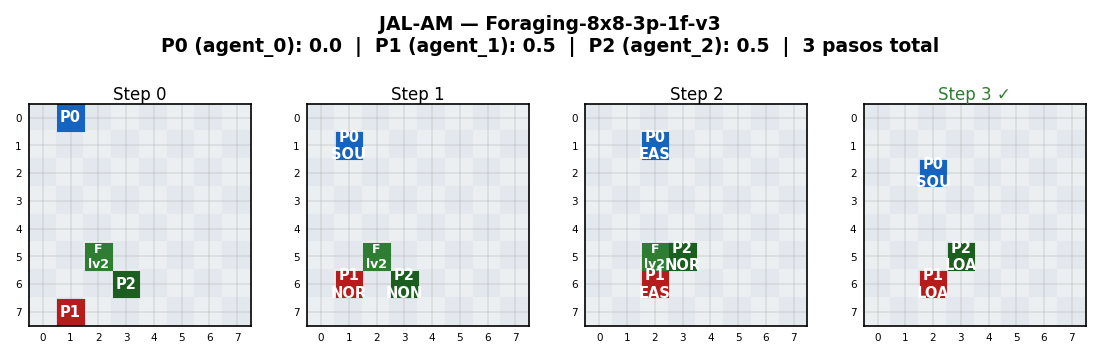

In [ ]:
show_trained_game(game_jalam_2, agents_jalam_2, f'JAL-AM — {configurations["2"]["game"]}')

#### Observaciones

En este experimento utilizando JAL-AM en `Foraging-8x8-3p-1f-v3` puede observarse un comportamiento bastante similar al obtenido previamente con IQL en la misma configuración.

Las recompensas muestran nuevamente un escenario desbalanceado entre agentes. Tanto `agent_1` como `agent_2` logran incrementar progresivamente sus recompensas promedio hasta estabilizarse alrededor de `0.4 - 0.45`, mientras que `agent_0` mantiene recompensas considerablemente menores durante gran parte del entrenamiento.

Aunque las curvas parecen ligeramente más suaves que en IQL, las diferencias generales entre ambos algoritmos no resultan demasiado marcadas en este entorno. Continúa observándose que algunos agentes logran adaptarse mejor que otros y terminan obteniendo la mayor parte de las recompensas disponibles.

La visualización del episodio entrenado muestra además una dinámica muy parecida a la observada previamente con IQL. Tanto `P1` como `P2` terminan cerca del recurso y obtienen recompensas compartidas, mientras que `P0` permanece considerablemente más alejado.

Las recompensas finales observadas fueron:

- `P0 = 0.0`
- `P1 = 0.5`
- `P2 = 0.5`

También resulta interesante observar que el agente con menores recompensas vuelve a coincidir con el agente más alejado de la comida durante el episodio. Esto podría indicar que pequeñas diferencias iniciales de posicionamiento o exploración terminan amplificándose durante el entrenamiento, favoreciendo sistemáticamente a ciertos agentes.

En conjunto, los resultados sugieren que, al menos en esta configuración de Foraging, JAL-AM no logra una mejora significativamente superior respecto a IQL en términos de balance entre agentes o coordinación global. Ambos algoritmos aprenden políticas útiles para alcanzar el recurso, aunque continúan apareciendo distribuciones desbalanceadas de recompensas entre jugadores.

#### JAL-AM × 2 + IQL × 1 — Config 2

P0 y P1 usan **JAL-AM**; P2 usa **IQL**.

=== JAL-AM×2 + IQL×1 — Foraging-8x8-3p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.1000, Observed state: [5. 2. 2. 1. 4. 2. 1. 6. 1. 1. 7. 1.]
  agent_1: 0.0600, Observed state: [5. 2. 2. 1. 6. 1. 1. 4. 2. 1. 7. 1.]
  agent_2: 0.0800, Observed state: [5. 2. 2. 1. 7. 1. 1. 4. 2. 1. 6. 1.]
Iteration 20 (2000 episodes)
  agent_0: 0.1700, Observed state: [-1. -1.  0.  3.  1.  2.  6.  2.  1.  5.  3.  1.]
  agent_1: 0.2050, Observed state: [-1. -1.  0.  6.  2.  1.  3.  1.  2.  5.  3.  1.]
  agent_2: 0.2050, Observed state: [-1. -1.  0.  5.  3.  1.  3.  1.  2.  6.  2.  1.]
Iteration 30 (3000 episodes)
  agent_0: 0.2483, Observed state: [-1. -1.  0.  1.  2.  2.  5.  1.  1.  5.  3.  1.]
  agent_1: 0.3042, Observed state: [-1. -1.  0.  5.  1.  1.  1.  2.  2.  5.  3.  1.]
  agent_2: 0.2975, Observed state: [-1. -1.  0.  5.  3.  1.  1.  2.  2.  5.  1.  1.]
Iteration 40 (4000 episodes)
  agent_0: 0.2100, Observed state: [-1. -1.  0.  3.  2.  2.  6.  2.  1.  5.  3.  1.]
  agent_1: 0.3500, Ob

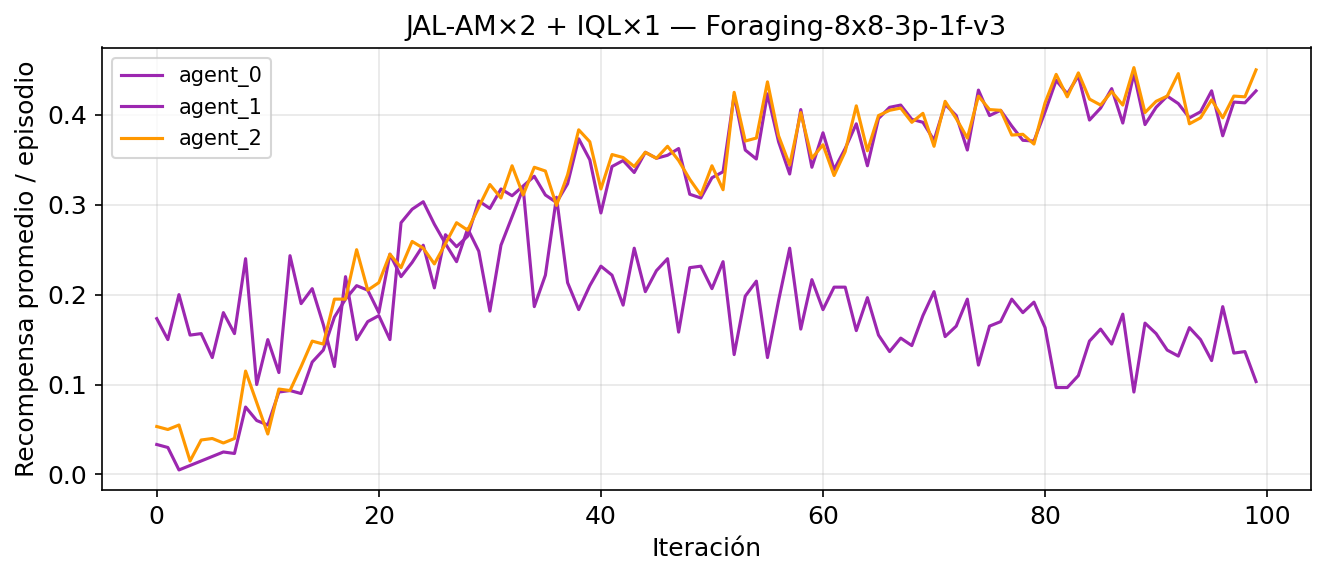

In [ ]:
# ── JAL-AM×2 + IQL×1 — Config 2: Foraging-8x8-3p-1f-v3 ──────────────────────
config = configurations['2']
game_jalam2iql_2 = Foraging(config=config['game'], seed=1)
agents_jalam2iql_2 = {
    game_jalam2iql_2.agents[0]: JointActionLearningAM(game=game_jalam2iql_2, agent=game_jalam2iql_2.agents[0], **config['jalam']),
    game_jalam2iql_2.agents[1]: JointActionLearningAM(game=game_jalam2iql_2, agent=game_jalam2iql_2.agents[1], **config['jalam']),
    game_jalam2iql_2.agents[2]: IndependentQLearning(game=game_jalam2iql_2, agent=game_jalam2iql_2.agents[2], **config['iql']),
}

print(f"=== JAL-AM×2 + IQL×1 — {config['game']} ===")
avg_jalam2iql_2 = train(game_jalam2iql_2, agents_jalam2iql_2, config['train_config'], progress=True)

plot_training(avg_jalam2iql_2,
              title=f"JAL-AM×2 + IQL×1 — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], COLORS['IQL']],
              save_path='figures/Foraging/jalam2iql_config2_training.png')

for a in game_jalam2iql_2.agents:
    agents_jalam2iql_2[a].epsilon = 0.0
    agents_jalam2iql_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


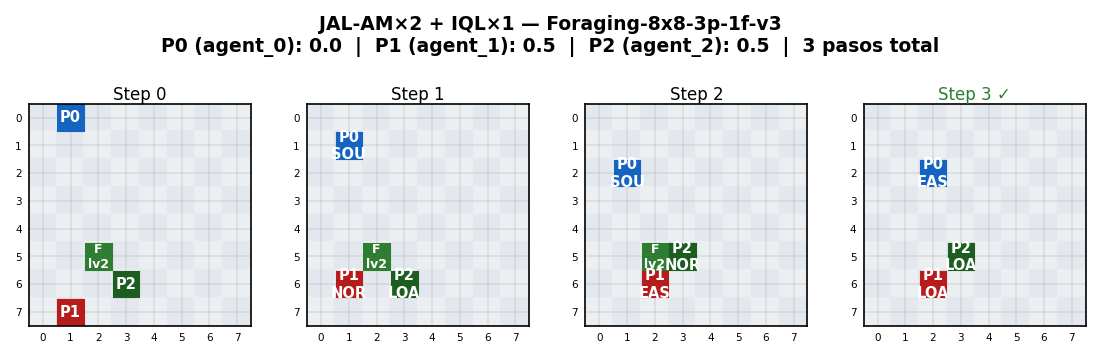

In [ ]:
show_trained_game(game_jalam2iql_2, agents_jalam2iql_2, f'JAL-AM×2 + IQL×1 — {configurations["2"]["game"]}')

#### Observaciones

En este experimento se evaluó una configuración mixta en `Foraging-8x8-3p-1f-v3`, donde `P0` y `P1` utilizan JAL-AM mientras que `P2` utiliza IQL.

Las recompensas muestran un comportamiento bastante similar al observado en los experimentos anteriores con tres agentes. Nuevamente, dos agentes logran incrementar progresivamente sus recompensas promedio hasta estabilizarse alrededor de `0.4 - 0.45`, mientras que un tercer agente mantiene recompensas considerablemente menores durante casi todo el entrenamiento.

En este caso, los agentes con mejor desempeño fueron `agent_1` y `agent_2`, mientras que `agent_0` quedó claramente rezagado. Resulta interesante observar que el agente basado en IQL (`P2`) no parece verse perjudicado frente a los agentes JAL-AM; por el contrario, termina obteniendo recompensas similares a las del mejor agente del entorno.

Esto sugiere que, al menos en esta configuración particular, utilizar JAL-AM no genera una ventaja claramente observable respecto a IQL en términos de recompensa final o capacidad de coordinación.

La visualización del episodio entrenado muestra nuevamente una dinámica de cooperación parcial entre dos agentes. Tanto `P1` como `P2` terminan realizando acciones cercanas al recurso y obtienen recompensas compartidas, mientras que `P0` permanece más alejado de la comida.

Las recompensas finales observadas fueron:

- `P0 = 0.0`
- `P1 = 0.5`
- `P2 = 0.5`

Además, el episodio vuelve a completarse en únicamente `3 pasos`, indicando que los agentes aprendieron trayectorias eficientes hacia el recurso dentro del entorno.

También puede observarse nuevamente el patrón visto en experimentos anteriores: el agente con menores recompensas coincide con el agente que termina más lejos de la comida durante el episodio. Esto refuerza la hipótesis de que pequeñas diferencias iniciales de posicionamiento o exploración pueden amplificarse durante el entrenamiento y terminar favoreciendo sistemáticamente a ciertos agentes.

En conjunto, los resultados sugieren que mezclar agentes JAL-AM e IQL no modifica significativamente la dinámica general observada en Foraging. Continúan apareciendo distribuciones desbalanceadas de recompensas, y la coordinación efectiva parece emerger únicamente entre algunos agentes del entorno.

#### IQL × 2 + JAL-AM × 1 — Config 2

P0 y P1 usan **IQL**; P2 usa **JAL-AM**.

=== IQL×2 + JAL-AM×1 — Foraging-8x8-3p-1f-v3 ===
Iteration 10 (1000 episodes)
  agent_0: 0.1400, Observed state: [-1. -1.  0.  1.  4.  2.  4.  2.  1.  0.  2.  2.]
  agent_1: 0.0850, Observed state: [-1. -1.  0.  4.  2.  1.  1.  4.  2.  0.  2.  2.]
  agent_2: 0.0650, Observed state: [-1. -1.  0.  0.  2.  2.  1.  4.  2.  4.  2.  1.]
Iteration 20 (2000 episodes)
  agent_0: 0.1200, Observed state: [-1. -1.  0.  2.  2.  2.  5.  1.  1.  5.  3.  1.]
  agent_1: 0.2750, Observed state: [-1. -1.  0.  5.  1.  1.  2.  2.  2.  5.  3.  1.]
  agent_2: 0.2950, Observed state: [-1. -1.  0.  5.  3.  1.  2.  2.  2.  5.  1.  1.]
Iteration 30 (3000 episodes)
  agent_0: 0.1933, Observed state: [-1. -1.  0.  4.  2.  2.  7.  2.  1.  7.  3.  1.]
  agent_1: 0.3100, Observed state: [-1. -1.  0.  7.  2.  1.  4.  2.  2.  7.  3.  1.]
  agent_2: 0.3167, Observed state: [-1. -1.  0.  7.  3.  1.  4.  2.  2.  7.  2.  1.]
Iteration 40 (4000 episodes)
  agent_0: 0.2317, Observed state: [-1. -1.  0.  1.  1.  2.  6.  2.  1

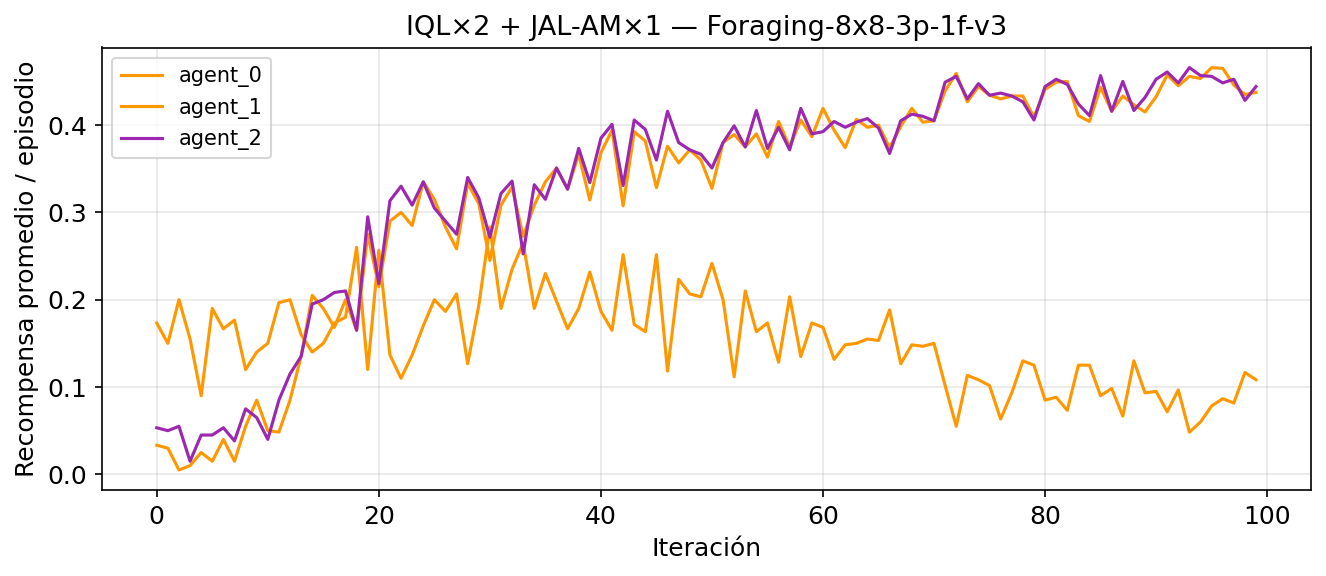

In [ ]:
# ── IQL×2 + JAL-AM×1 — Config 2: Foraging-8x8-3p-1f-v3 ──────────────────────
config = configurations['2']
game_iql2jalam_2 = Foraging(config=config['game'], seed=1)
agents_iql2jalam_2 = {
    game_iql2jalam_2.agents[0]: IndependentQLearning(game=game_iql2jalam_2, agent=game_iql2jalam_2.agents[0], **config['iql']),
    game_iql2jalam_2.agents[1]: IndependentQLearning(game=game_iql2jalam_2, agent=game_iql2jalam_2.agents[1], **config['iql']),
    game_iql2jalam_2.agents[2]: JointActionLearningAM(game=game_iql2jalam_2, agent=game_iql2jalam_2.agents[2], **config['jalam']),
}

print(f"=== IQL×2 + JAL-AM×1 — {config['game']} ===")
avg_iql2jalam_2 = train(game_iql2jalam_2, agents_iql2jalam_2, config['train_config'], progress=True)

plot_training(avg_iql2jalam_2,
              title=f"IQL×2 + JAL-AM×1 — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', JAL_AM_PALETTE[0]],
              save_path='figures/Foraging/iql2jalam_config2_training.png')

for a in game_iql2jalam_2.agents:
    agents_iql2jalam_2[a].epsilon = 0.0
    agents_iql2jalam_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


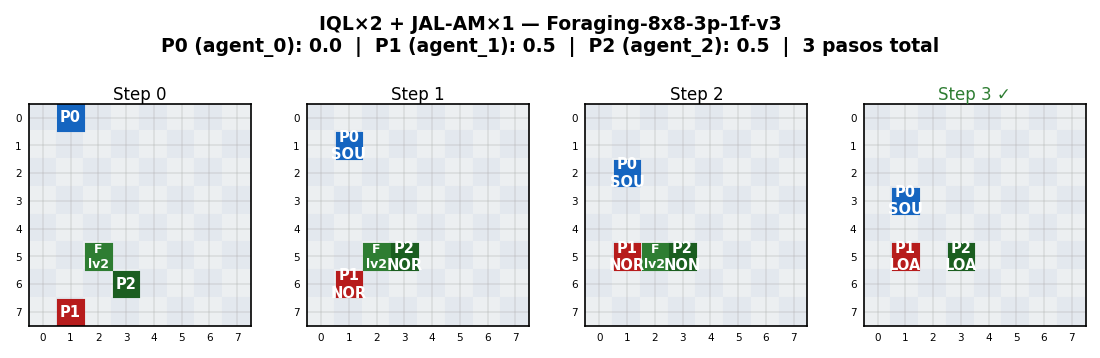

In [ ]:
show_trained_game(game_iql2jalam_2, agents_iql2jalam_2, f'IQL×2 + JAL-AM×1 — {configurations["2"]["game"]}')

#### Observaciones

En este experimento se evaluó una configuración mixta en `Foraging-8x8-3p-1f-v3`, donde `P0` y `P1` utilizan IQL mientras que `P2` utiliza JAL-AM.

Las recompensas muestran nuevamente un escenario desbalanceado entre agentes. Tanto `agent_1` como `agent_2` logran incrementar progresivamente sus recompensas promedio hasta estabilizarse alrededor de `0.4 - 0.45`, mientras que `agent_0` mantiene recompensas considerablemente menores durante gran parte del entrenamiento.

Resulta interesante observar que el agente JAL-AM (`P2`) obtiene recompensas similares a uno de los agentes IQL (`P1`), mientras que el otro agente IQL (`P0`) queda claramente relegado. Esto sugiere que el tipo de algoritmo utilizado no parece ser el único factor determinante del desempeño dentro de este entorno.

Las curvas presentan una evolución relativamente estable luego de las primeras iteraciones, indicando que los agentes logran aprender estrategias eficientes para alcanzar rápidamente el recurso disponible.

La visualización del episodio entrenado muestra nuevamente una dinámica de cooperación parcial entre dos agentes. En este caso, `P1` y `P2` terminan ejecutando acciones `LOAD` cerca de la comida y obtienen recompensas compartidas, mientras que `P0` permanece más alejado del recurso.

Las recompensas finales observadas fueron:

- `P0 = 0.0`
- `P1 = 0.5`
- `P2 = 0.5`

Además, el episodio vuelve a completarse en únicamente `3 pasos`, mostrando que los agentes aprendieron trayectorias muy eficientes dentro del mapa.

Al igual que en los experimentos anteriores, vuelve a observarse que el agente con peores recompensas coincide con el agente que termina más lejos de la comida durante el episodio. Esto refuerza la hipótesis de que pequeñas diferencias iniciales de posicionamiento o exploración pueden amplificarse durante el entrenamiento y favorecer sistemáticamente a ciertos agentes.

En conjunto, los resultados sugieren que combinar IQL y JAL-AM no modifica significativamente la dinámica general observada en Foraging. Continúan apareciendo distribuciones desbalanceadas de recompensas y la cooperación efectiva parece emerger únicamente entre algunos agentes del entorno, independientemente del algoritmo utilizado.

### Configuración 3 — `Foraging-8x8-3p-1f-coop-v3`

Grilla 8×8, **3 jugadores**, 1 ítem, **modo cooperativo** (`force_coop=True`). La cooperación es obligatoria en todos los episodios. Horizonte largo: 100 iteraciones × 1 000 episodios = 100 000 episodios totales.

=== IQL — Foraging-8x8-3p-1f-coop-v3 ===
Iteration 10 (10000 episodes)
  agent_0: 0.4310
  agent_1: 0.2155
  agent_2: 0.2155
Iteration 20 (20000 episodes)
  agent_0: 0.4760
  agent_1: 0.2380
  agent_2: 0.2380
Iteration 30 (30000 episodes)
  agent_0: 0.4900
  agent_1: 0.2450
  agent_2: 0.2450
Iteration 40 (40000 episodes)
  agent_0: 0.4950
  agent_1: 0.2475
  agent_2: 0.2475
Iteration 50 (50000 episodes)
  agent_0: 0.4925
  agent_1: 0.2462
  agent_2: 0.2462
Iteration 60 (60000 episodes)
  agent_0: 0.4965
  agent_1: 0.2482
  agent_2: 0.2482
Iteration 70 (70000 episodes)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497
Iteration 80 (80000 episodes)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497
Iteration 90 (90000 episodes)
  agent_0: 0.4990
  agent_1: 0.2495
  agent_2: 0.2495
Iteration 100 (100000 episodes)
  agent_0: 0.4985
  agent_1: 0.2492
  agent_2: 0.2492

Final — 100 iters × 1000 eps = 100000 total episodes
  agent_0: 0.4985
  agent_1: 0.2492
  agent_2: 0.2492


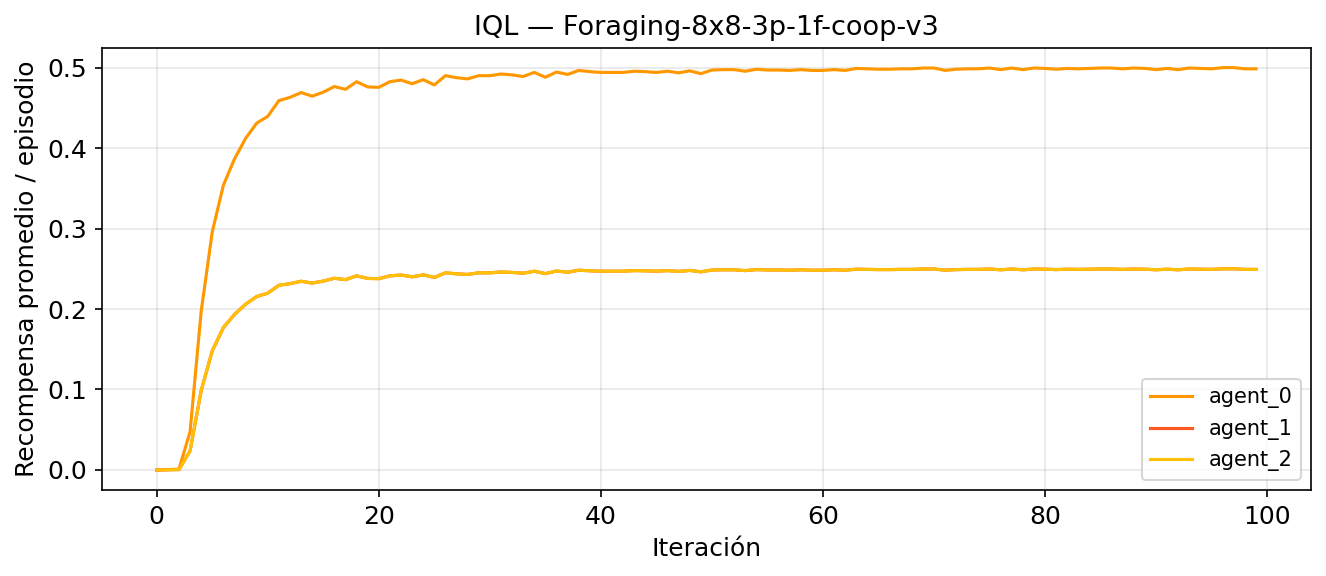

In [ ]:
# ── IQL — Config 3: Foraging-8x8-3p-1f-coop-v3 ───────────────────────────────
config = configurations['3']
game_iql_3 = Foraging(config=config['game'], seed=1)
agents_iql_3 = {a: IndependentQLearning(game=game_iql_3, agent=a, **config['iql'])
                for a in game_iql_3.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_3 = train(game_iql_3, agents_iql_3, config['train_config'], progress=True)

plot_training(avg_iql_3,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', '#FFC107'],
              save_path='figures/Foraging/iql_config3_training.png')

for a in game_iql_3.agents:
    agents_iql_3[a].epsilon = 0.0
    agents_iql_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


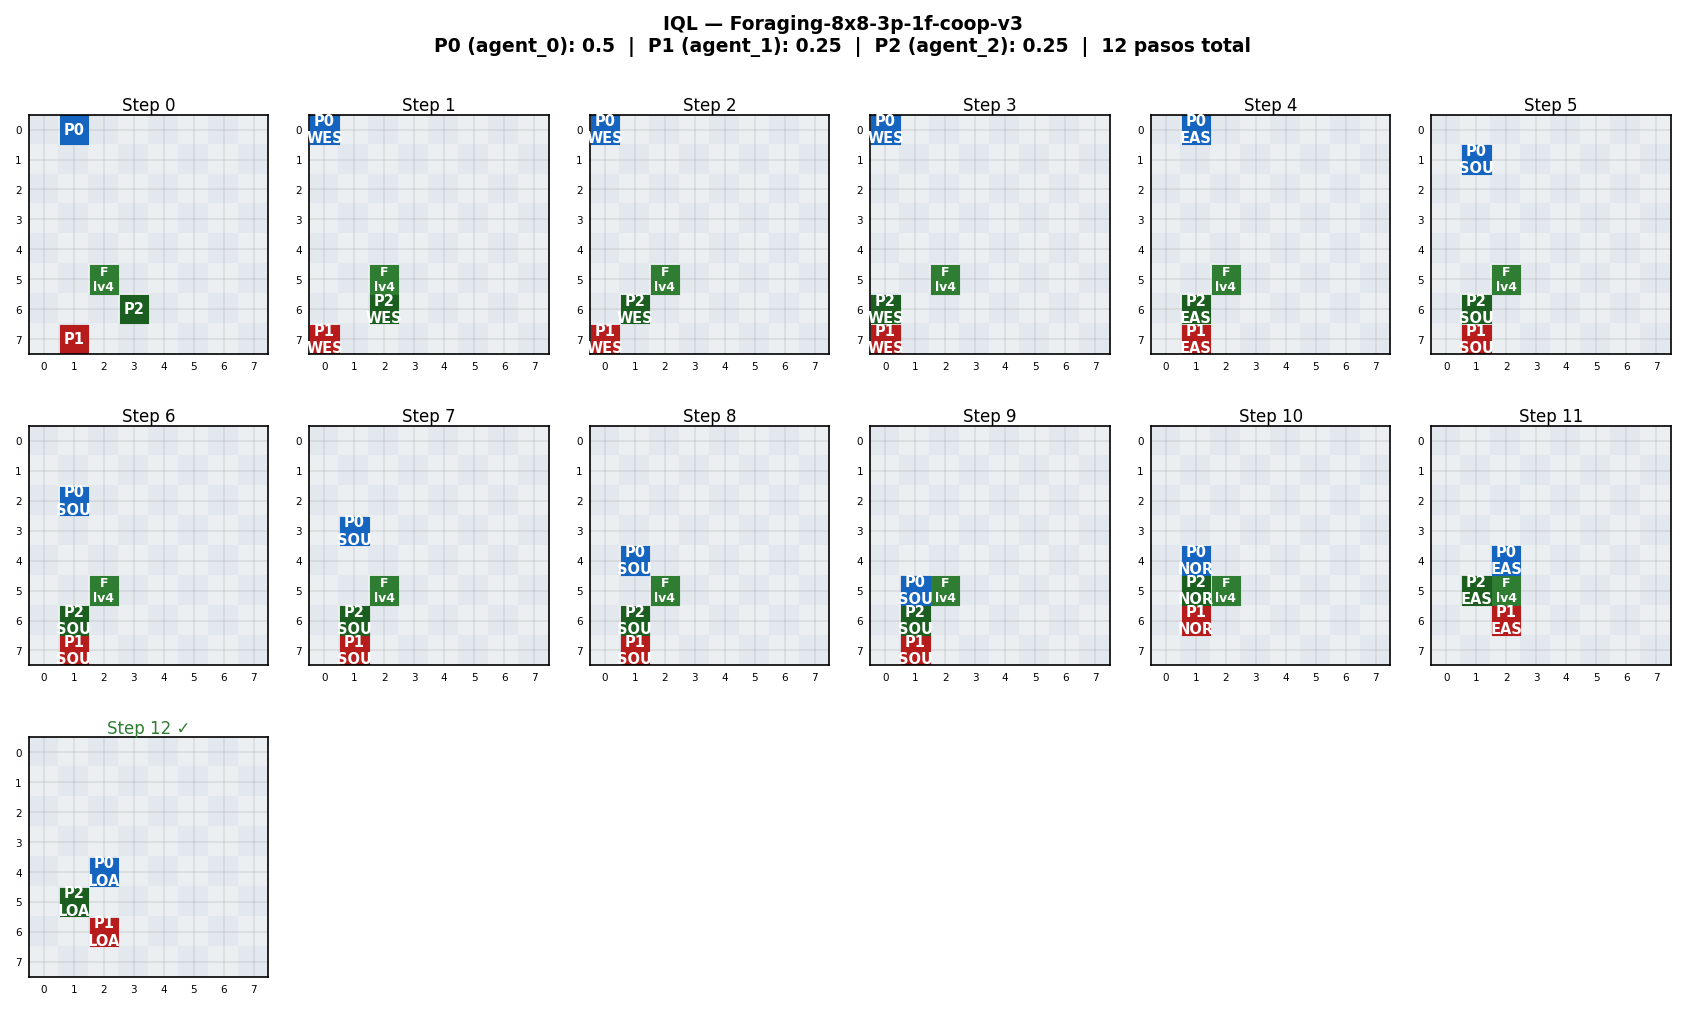

In [ ]:
show_trained_game(game_iql_3, agents_iql_3, f'IQL — {configurations["3"]["game"]}')

#### Observaciones

En este experimento se evaluó una configuración cooperativa utilizando IQL en `Foraging-8x8-3p-1f-coop-v3`.

A diferencia de los escenarios anteriores, aquí puede observarse un comportamiento considerablemente más coordinado entre los agentes. Las recompensas muestran una convergencia muy rápida durante las primeras iteraciones y luego permanecen extremadamente estables durante el resto del entrenamiento.

Además, las recompensas no aparecen tan desbalanceadas como en los experimentos no cooperativos. Aunque `agent_0` obtiene una recompensa promedio mayor (cercana a `0.5`), tanto `agent_1` como `agent_2` logran mantener recompensas relativamente similares y estables alrededor de `0.25`.

Esto sugiere que la configuración cooperativa modifica significativamente la dinámica del aprendizaje. En lugar de competir implícitamente por alcanzar primero el recurso, los agentes parecen desarrollar estrategias donde colaborar resulta beneficioso para todos.

La visualización del episodio entrenado refuerza claramente esta idea. Durante gran parte del episodio puede observarse cómo los tres agentes convergen progresivamente hacia la posición de la comida y permanecen relativamente agrupados cerca del recurso.

Además, el recurso posee:

- `food level = 4`

mientras que los agentes parecen tener niveles menores individualmente, por lo que la cooperación resulta necesaria para poder ejecutar exitosamente la acción `LOAD`.

Las recompensas finales observadas fueron:

- `P0 = 0.5`
- `P1 = 0.25`
- `P2 = 0.25`

Esto indica que múltiples agentes participan efectivamente de la recolección del recurso y comparten las recompensas obtenidas.

También puede observarse que el episodio requiere `12 pasos`, considerablemente más que en configuraciones anteriores. Esto tiene sentido, ya que los agentes deben coordinar movimientos y esperar a encontrarse cerca del recurso antes de poder recolectarlo exitosamente.

En comparación con los escenarios no cooperativos, aquí ya no se observa un agente completamente relegado o permanentemente alejado de la comida. Por el contrario, todos los agentes terminan participando activamente del objetivo compartido.

En conjunto, los resultados muestran que la configuración cooperativa favorece significativamente la coordinación entre agentes y reduce los comportamientos competitivos observados previamente en IQL.

=== JAL-AM — Foraging-8x8-3p-1f-coop-v3 ===
Iteration 10 (10000 episodes)
  agent_0: 0.4260
  agent_1: 0.2130
  agent_2: 0.2130
Iteration 20 (20000 episodes)
  agent_0: 0.4750
  agent_1: 0.2375
  agent_2: 0.2375
Iteration 30 (30000 episodes)
  agent_0: 0.4880
  agent_1: 0.2440
  agent_2: 0.2440
Iteration 40 (40000 episodes)
  agent_0: 0.4920
  agent_1: 0.2460
  agent_2: 0.2460
Iteration 50 (50000 episodes)
  agent_0: 0.4935
  agent_1: 0.2467
  agent_2: 0.2467
Iteration 60 (60000 episodes)
  agent_0: 0.4990
  agent_1: 0.2495
  agent_2: 0.2495
Iteration 70 (70000 episodes)
  agent_0: 0.4970
  agent_1: 0.2485
  agent_2: 0.2485
Iteration 80 (80000 episodes)
  agent_0: 0.4990
  agent_1: 0.2495
  agent_2: 0.2495
Iteration 90 (90000 episodes)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497
Iteration 100 (100000 episodes)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497

Final — 100 iters × 1000 eps = 100000 total episodes
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497


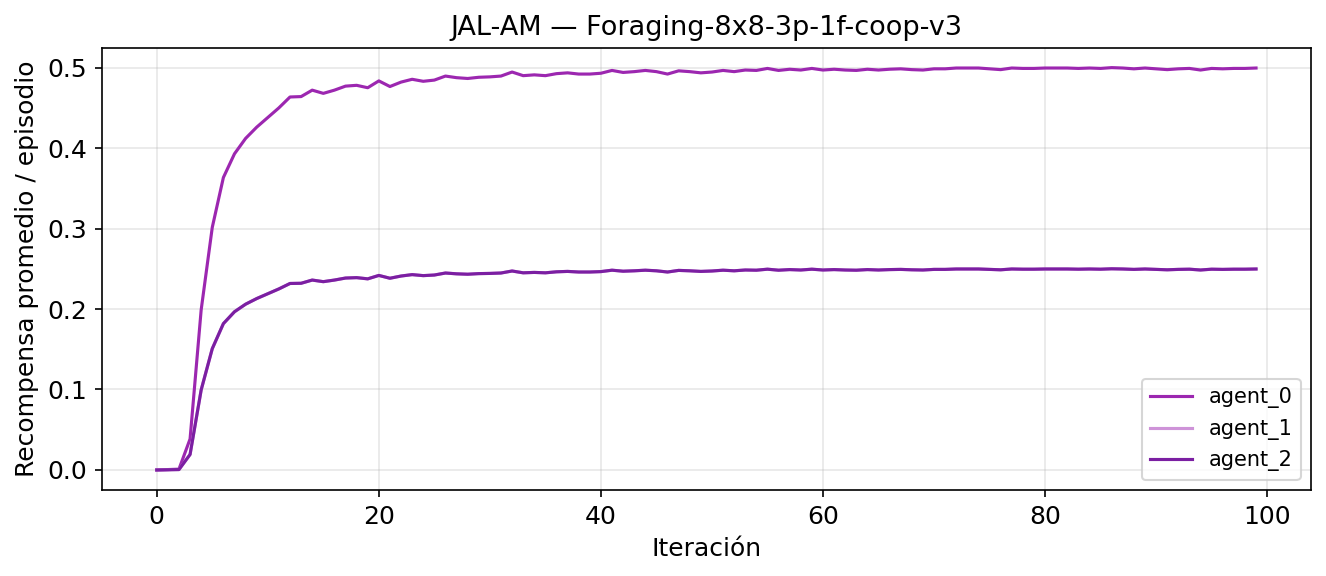

In [ ]:
# ── JAL-AM — Config 3: Foraging-8x8-3p-1f-coop-v3 ────────────────────────────
config = configurations['3']
game_jalam_3 = Foraging(config=config['game'], seed=1)
agents_jalam_3 = {a: JointActionLearningAM(game=game_jalam_3, agent=a, **config['jalam'])
                  for a in game_jalam_3.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_3 = train(game_jalam_3, agents_jalam_3, config['train_config'], progress=True)

plot_training(avg_jalam_3,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], JAL_AM_PALETTE[2]],
              save_path='figures/Foraging/jalam_config3_training.png')

for a in game_jalam_3.agents:
    agents_jalam_3[a].epsilon = 0.0
    agents_jalam_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


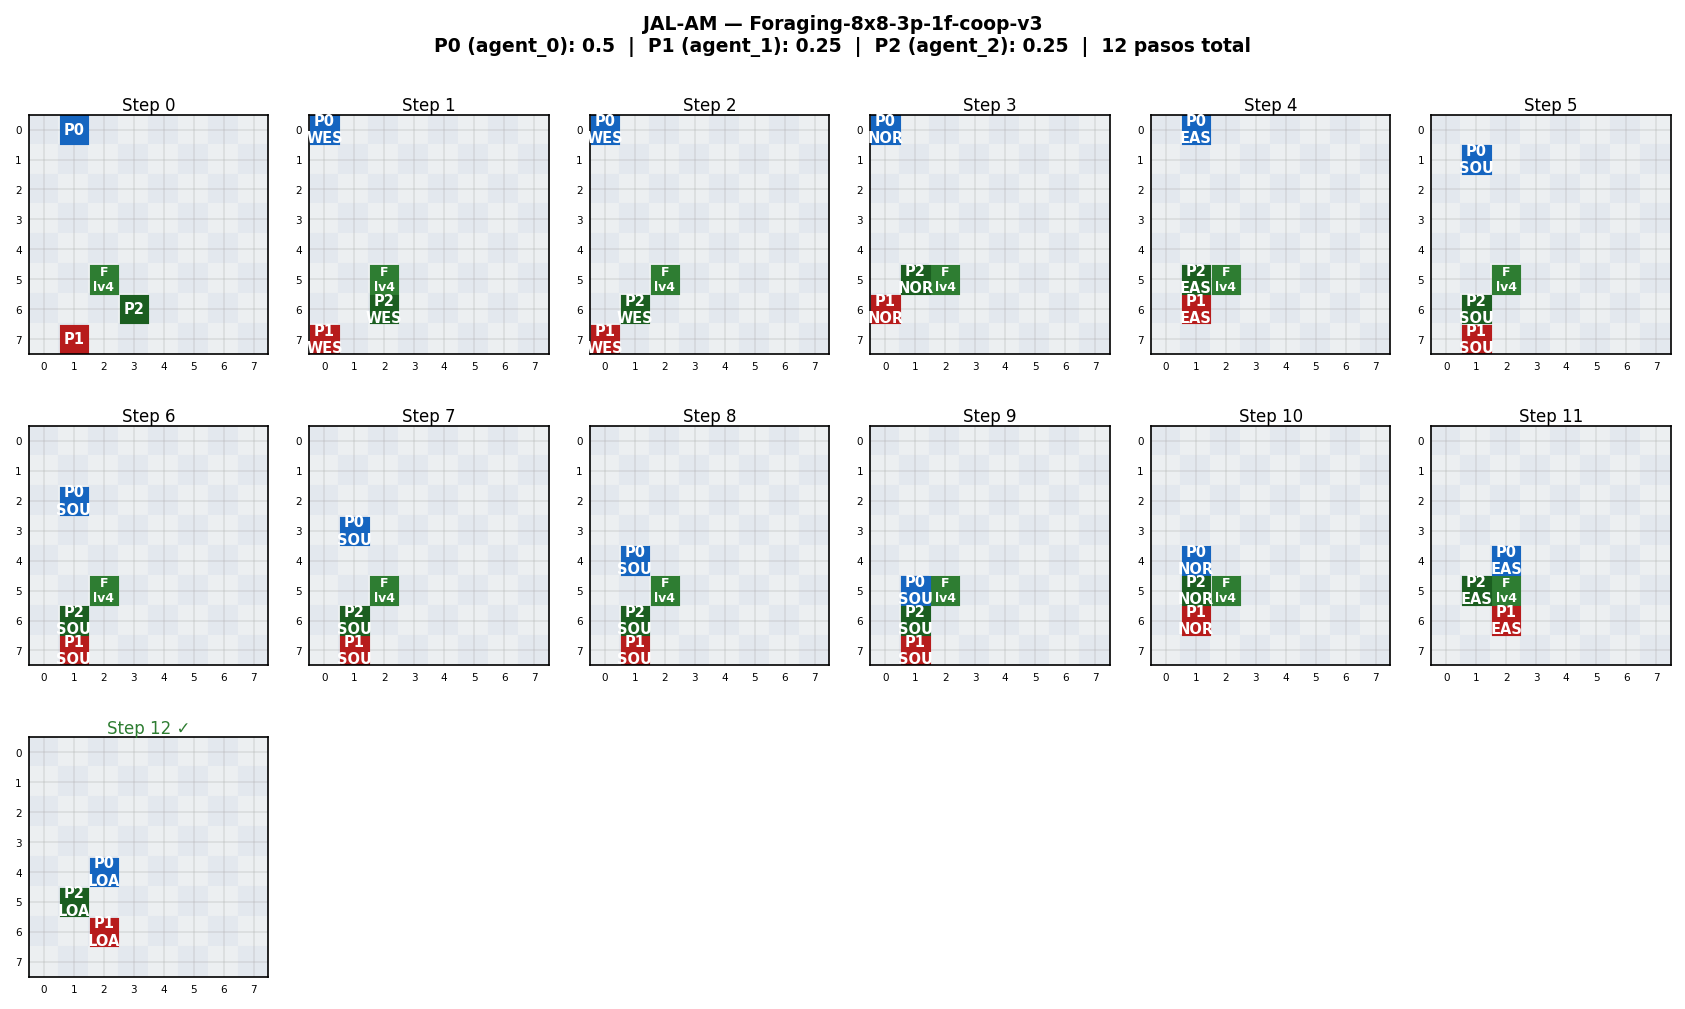

In [ ]:
show_trained_game(game_jalam_3, agents_jalam_3, f'JAL-AM — {configurations["3"]["game"]}')

#### JAL-AM × 2 + IQL × 1 — Config 3

P0 y P1 usan **JAL-AM**; P2 usa **IQL**. Modo cooperativo.

=== JAL-AM×2 + IQL×1 — Foraging-8x8-3p-1f-coop-v3 ===
Iteration 10 (10000 episodes)
  agent_0: 0.4645, Observed state: [-1. -1.  0.  4.  2.  2.  6.  2.  1.  5.  1.  1.]
  agent_1: 0.2323, Observed state: [-1. -1.  0.  6.  2.  1.  4.  2.  2.  5.  1.  1.]
  agent_2: 0.2323, Observed state: [-1. -1.  0.  5.  1.  1.  4.  2.  2.  6.  2.  1.]
Iteration 20 (20000 episodes)
  agent_0: 0.4965, Observed state: [-1. -1.  0.  4.  2.  2.  6.  2.  1.  5.  1.  1.]
  agent_1: 0.2482, Observed state: [-1. -1.  0.  6.  2.  1.  4.  2.  2.  5.  1.  1.]
  agent_2: 0.2482, Observed state: [-1. -1.  0.  5.  1.  1.  4.  2.  2.  6.  2.  1.]
Iteration 30 (30000 episodes)
  agent_0: 0.4980, Observed state: [-1. -1.  0.  4.  2.  2.  6.  2.  1.  5.  1.  1.]
  agent_1: 0.2490, Observed state: [-1. -1.  0.  6.  2.  1.  4.  2.  2.  5.  1.  1.]
  agent_2: 0.2490, Observed state: [-1. -1.  0.  5.  1.  1.  4.  2.  2.  6.  2.  1.]
Iteration 40 (40000 episodes)
  agent_0: 0.5000, Observed state: [-1. -1.  0.  4.  2.  2.  

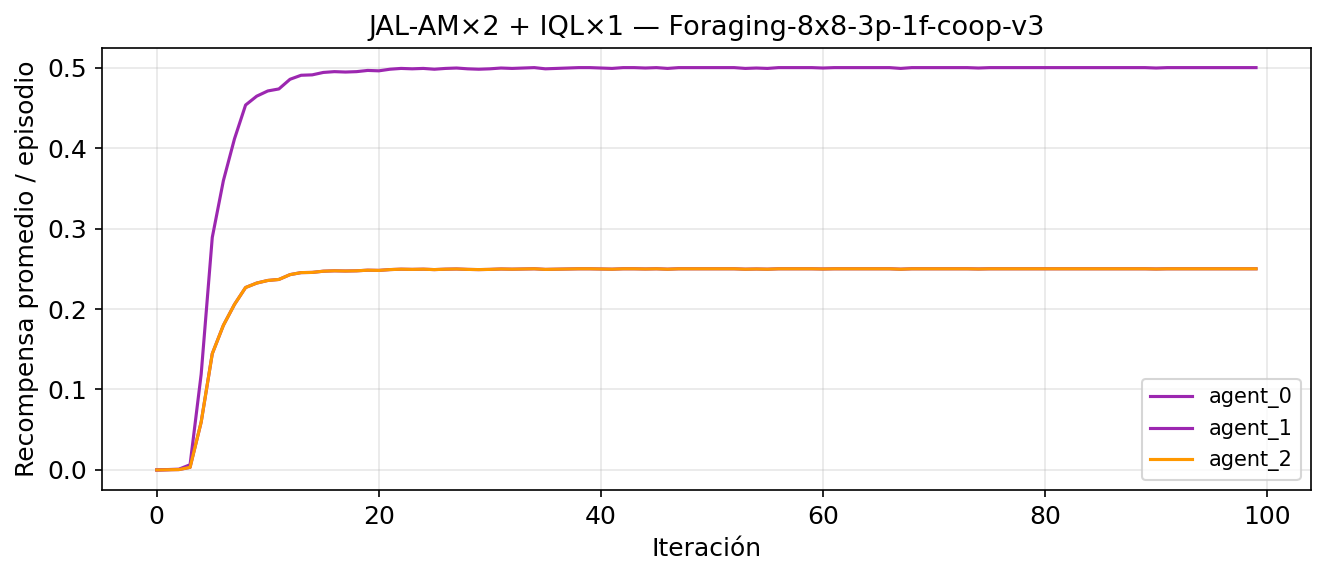

In [ ]:
# ── JAL-AM×2 + IQL×1 — Config 3: Foraging-8x8-3p-1f-coop-v3 ─────────────────
config = configurations['3']
game_jalam2iql_3 = Foraging(config=config['game'], seed=1)
agents_jalam2iql_3 = {
    game_jalam2iql_3.agents[0]: JointActionLearningAM(game=game_jalam2iql_3, agent=game_jalam2iql_3.agents[0], **config['jalam']),
    game_jalam2iql_3.agents[1]: JointActionLearningAM(game=game_jalam2iql_3, agent=game_jalam2iql_3.agents[1], **config['jalam']),
    game_jalam2iql_3.agents[2]: IndependentQLearning(game=game_jalam2iql_3, agent=game_jalam2iql_3.agents[2], **config['iql']),
}

print(f"=== JAL-AM×2 + IQL×1 — {config['game']} ===")
avg_jalam2iql_3 = train(game_jalam2iql_3, agents_jalam2iql_3, config['train_config'], progress=True)

plot_training(avg_jalam2iql_3,
              title=f"JAL-AM×2 + IQL×1 — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], COLORS['IQL']],
              save_path='figures/Foraging/jalam2iql_config3_training.png')

for a in game_jalam2iql_3.agents:
    agents_jalam2iql_3[a].epsilon = 0.0
    agents_jalam2iql_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


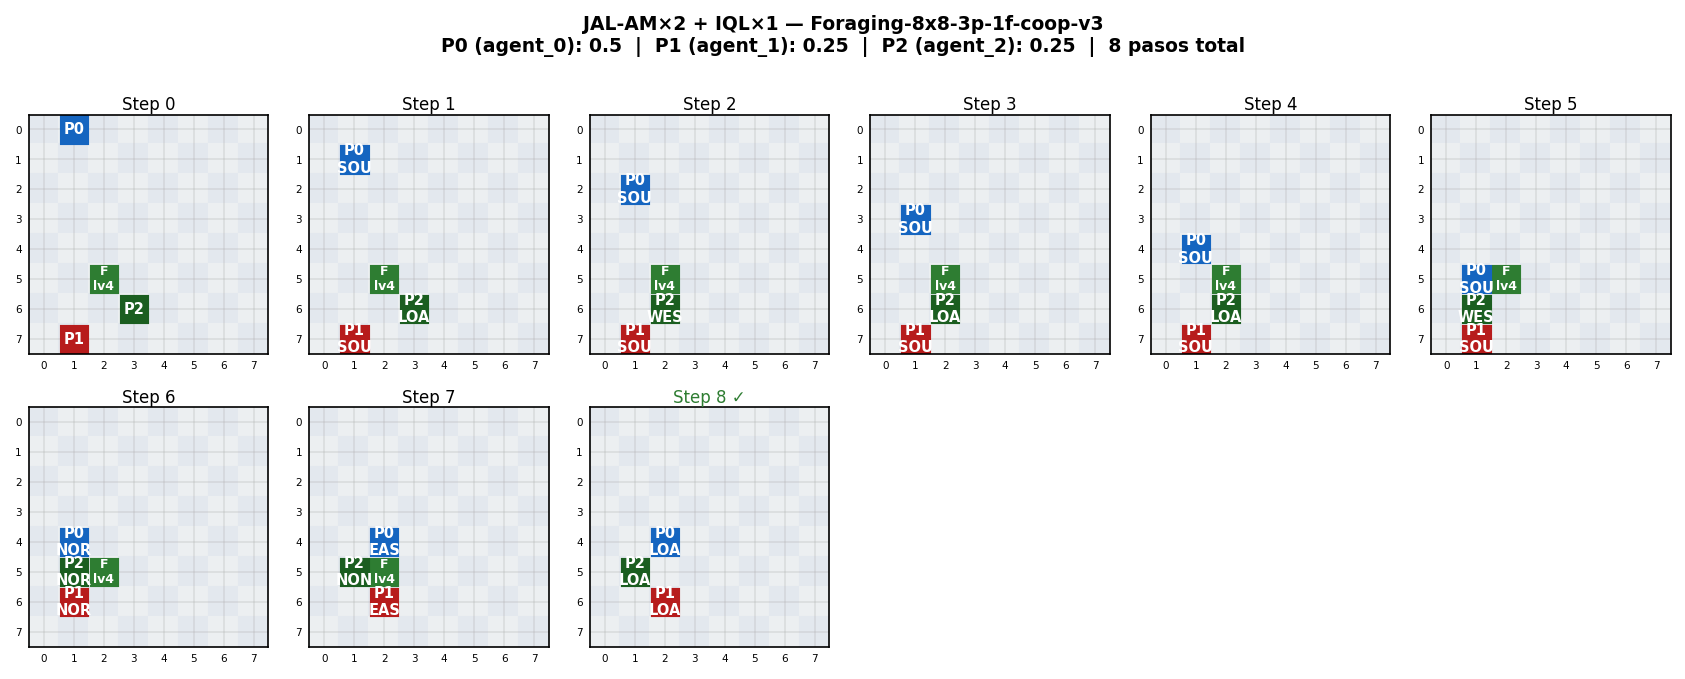

In [ ]:
show_trained_game(game_jalam2iql_3, agents_jalam2iql_3, f'JAL-AM×2 + IQL×1 — {configurations["3"]["game"]}')

#### IQL × 2 + JAL-AM × 1 — Config 3

P0 y P1 usan **IQL**; P2 usa **JAL-AM**. Modo cooperativo.

=== IQL×2 + JAL-AM×1 — Foraging-8x8-3p-1f-coop-v3 ===
Iteration 10 (10000 episodes)
  agent_0: 0.4660, Observed state: [-1. -1.  0.  4.  2.  2.  6.  2.  1.  5.  1.  1.]
  agent_1: 0.2330, Observed state: [-1. -1.  0.  6.  2.  1.  4.  2.  2.  5.  1.  1.]
  agent_2: 0.2330, Observed state: [-1. -1.  0.  5.  1.  1.  4.  2.  2.  6.  2.  1.]
Iteration 20 (20000 episodes)
  agent_0: 0.4950, Observed state: [-1. -1.  0.  4.  2.  2.  6.  2.  1.  5.  1.  1.]
  agent_1: 0.2475, Observed state: [-1. -1.  0.  6.  2.  1.  4.  2.  2.  5.  1.  1.]
  agent_2: 0.2475, Observed state: [-1. -1.  0.  5.  1.  1.  4.  2.  2.  6.  2.  1.]
Iteration 30 (30000 episodes)
  agent_0: 0.5000, Observed state: [-1. -1.  0.  4.  2.  2.  6.  2.  1.  5.  1.  1.]
  agent_1: 0.2500, Observed state: [-1. -1.  0.  6.  2.  1.  4.  2.  2.  5.  1.  1.]
  agent_2: 0.2500, Observed state: [-1. -1.  0.  5.  1.  1.  4.  2.  2.  6.  2.  1.]
Iteration 40 (40000 episodes)
  agent_0: 0.5000, Observed state: [-1. -1.  0.  4.  2.  2.  

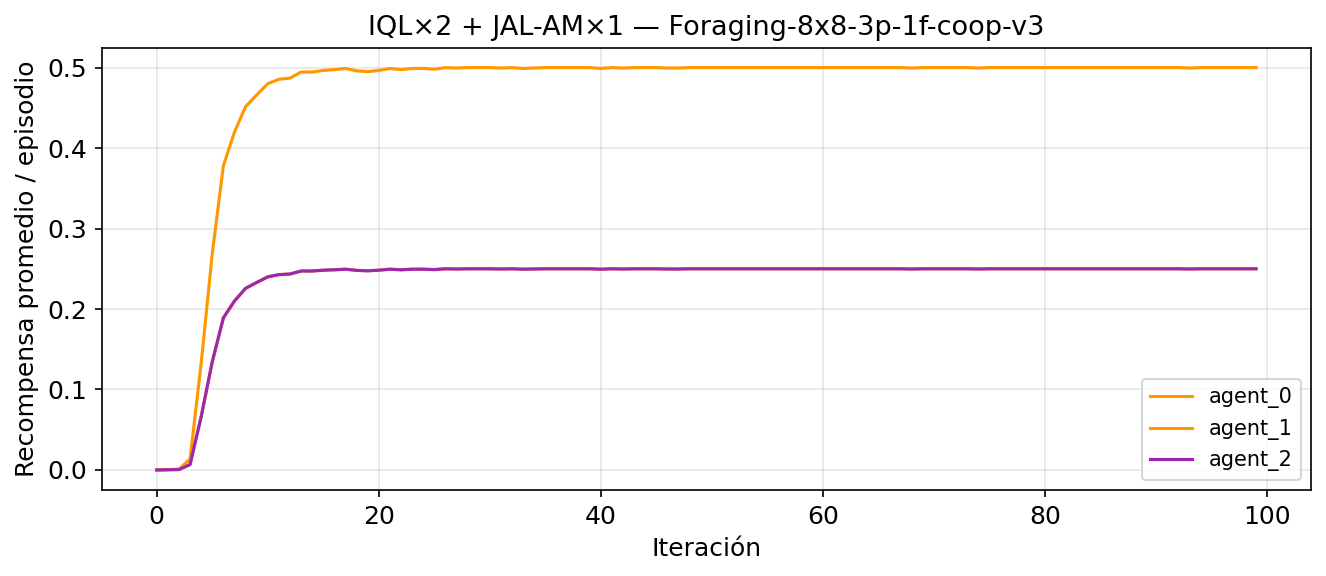

In [ ]:
# ── IQL×2 + JAL-AM×1 — Config 3: Foraging-8x8-3p-1f-coop-v3 ─────────────────
config = configurations['3']
game_iql2jalam_3 = Foraging(config=config['game'], seed=1)
agents_iql2jalam_3 = {
    game_iql2jalam_3.agents[0]: IndependentQLearning(game=game_iql2jalam_3, agent=game_iql2jalam_3.agents[0], **config['iql']),
    game_iql2jalam_3.agents[1]: IndependentQLearning(game=game_iql2jalam_3, agent=game_iql2jalam_3.agents[1], **config['iql']),
    game_iql2jalam_3.agents[2]: JointActionLearningAM(game=game_iql2jalam_3, agent=game_iql2jalam_3.agents[2], **config['jalam']),
}

print(f"=== IQL×2 + JAL-AM×1 — {config['game']} ===")
avg_iql2jalam_3 = train(game_iql2jalam_3, agents_iql2jalam_3, config['train_config'], progress=True)

plot_training(avg_iql2jalam_3,
              title=f"IQL×2 + JAL-AM×1 — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', JAL_AM_PALETTE[0]],
              save_path='figures/Foraging/iql2jalam_config3_training.png')

for a in game_iql2jalam_3.agents:
    agents_iql2jalam_3[a].epsilon = 0.0
    agents_iql2jalam_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_82438/3504133080.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


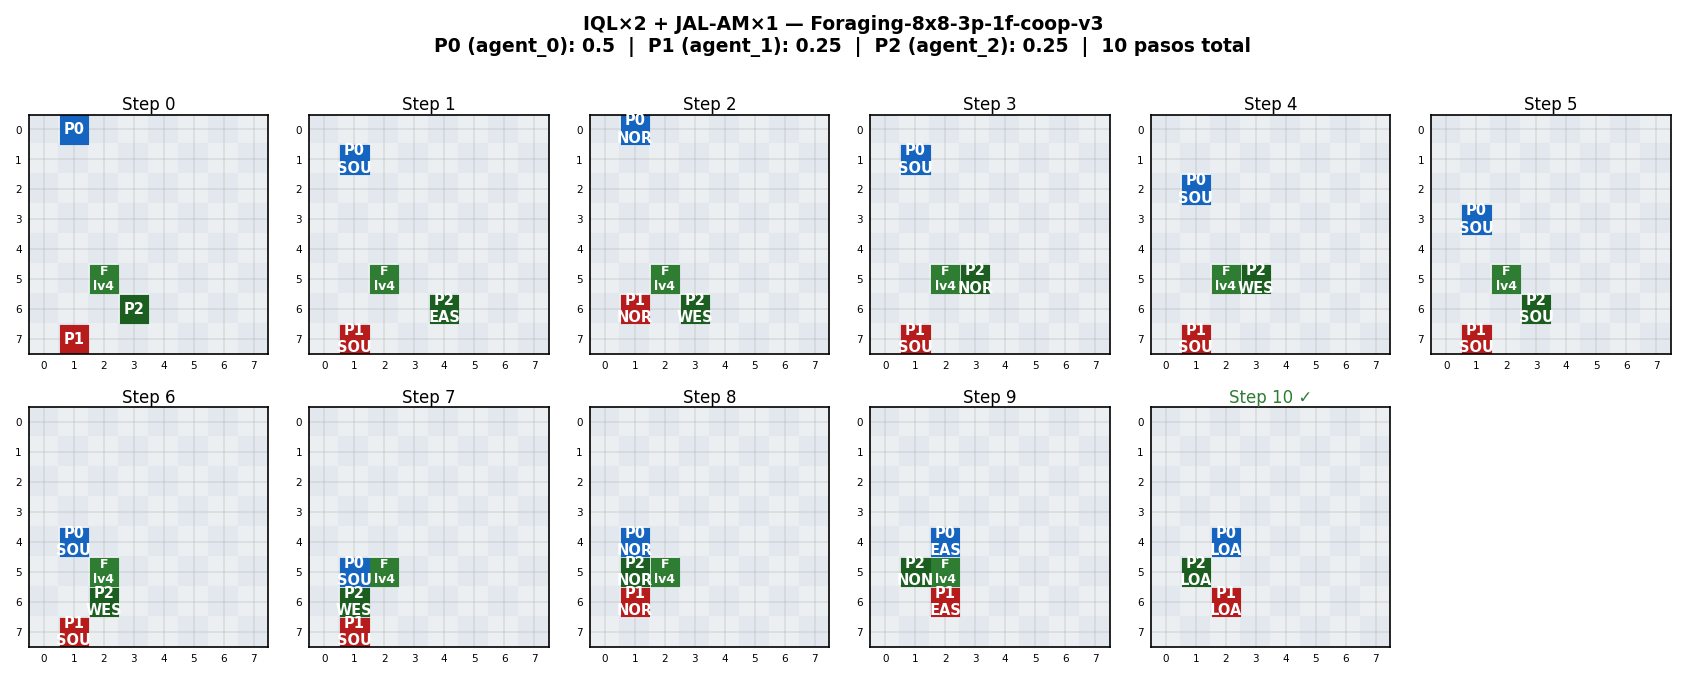

In [ ]:
show_trained_game(game_iql2jalam_3, agents_iql2jalam_3, f'IQL×2 + JAL-AM×1 — {configurations["3"]["game"]}')

## Conclusión

Un aspecto interesante observado durante los experimentos es que los agentes con menores recompensas suelen aparecer también más alejados del recurso durante los episodios visualizados.

Dado que las posiciones iniciales del entorno son aleatorias, pequeñas ventajas iniciales podrían amplificarse durante el entrenamiento. Los agentes que logran alcanzar el recurso con mayor frecuencia en etapas tempranas obtienen más recompensas y, en consecuencia, aprenden políticas más efectivas, mientras que otros agentes quedan progresivamente rezagados.

Este comportamiento parece ser particularmente visible en algoritmos como IQL, donde no existe coordinación explícita entre agentes y cada uno aprende de manera independiente.